# **GLOBAL PROJECT**


ALUMNO 1: Alberto Miranda   
ALUMNO 2: María José Mangas Gutiérrez  
ALUMNO 3: Santiago Ricardo José Mendoza   

#### **PROGRAMA:**
Máster en Data Science y Big Data


#### **NOMBRE DEL PROYECTO:**
Análisis y predicción espacio-temporal de la demanda en servicios de ride-hailing mediante técnicas de Big Data y aprendizaje automático.


### **Solución estructurada:**
#### **Capa 1: Capture**     
Data Sources:   
•	Chicago Taxi Trips Dataset   
•	Chicago Taxi Zones   
•	NOAA Weather Dataset   
•	Calendario/Festivos   
•	Chicago Traffic Crashes (V3)   
•	Chicago Traffic Congestion by Region (V3)

Complementarios:    
• Uber Pickups NYC   
• Uber/Lyft Prices

#### **Capa 2: Ingest**    
Data Ingestion:    
•	Descarga de datasets: Kaggle, APIs (Chicago, NOAA), Híbrida.   
•	Conversión de formatos (si se requiere)  
•	Organización de archivos por dataset   
•	Preparación para su procesamiento con Spark.    

#### **Capa 3: Store**   
Data Store:    
•	Almacenamiento en Data Lake (raw): CSV originales en Drive  
•	Archivos en formato CSV o Parquet.      
• Organización por carpetas según fuente de datos (uber_nyc, prices, etc)     

#### **Capa 4: Compute**  
Data Processing (Apache Spark/ PySpark):     
• Cargar en Spark  
•	Limpieza y preparación de datos:Transformación, joins, análisis  
•	Integración de viajes con clima   
•	Agregación por zona y hora.   

Feature Engineering:  
•	Variables temporales  
•	Variables espaciales  
•	Variables meteorológicas  

Machine Learning:    
  Modelado predictivo:    
•	Linear Regression   
•	Random Forest   
•	Gradient Boosting  

  Evaluación del Modelo: métricas estándar de regresión.   
•	MAE (Mean Absolute Error)  
•	RMSE (Root Mean Squared Error)  
•	MAPE (Mean Absolute Percentage Error)  

#### **Capa 5: Use**   
Visualization:     
•	Dashboard interactivo   
•	Aplicación (Streamlit) para la toma de decisiones  






### Problema a resolver

El objetivo de este proyecto es predecir la demanda de servicios de ride-hailing en la ciudad de Chicago, considerando variables espaciales, temporales y meteorológicas.

La correcta estimación de la demanda permite optimizar la asignación de recursos, reducir tiempos de espera y mejorar la eficiencia operativa en sistemas de transporte urbano.

Este problema presenta desafíos relevantes debido a la naturaleza no lineal de la demanda, la heterogeneidad de las fuentes de datos y la necesidad de integrar información en distintas escalas temporales.

### Justificación del uso de Apache Spark

Se seleccionó Apache Spark como motor de procesamiento debido a su capacidad para manejar grandes volúmenes de datos de forma distribuida, permitiendo realizar transformaciones complejas y joins entre múltiples datasets de manera eficiente.

El uso de Spark resulta especialmente relevante en este proyecto debido a la integración de fuentes heterogéneas y al potencial escalamiento del volumen de datos en escenarios reales.

# Capa 1: Capture


### Data Sources

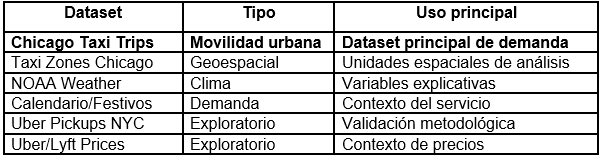

> **Nota (V3).** El diagrama anterior corresponde a la versión original del proyecto. La tabla de texto actualizada, con las dos fuentes incorporadas en esta versión (Traffic Crashes y Traffic Congestion by Region), está en **Data Sources URL** justo debajo.


#### Data Sources URL:


• **Chicago Taxi Trips Dataset** ->  https://data.cityofchicago.org/resource/wrvz-psew.csv  
• **Chicago Taxi Zones** ->  https://data.cityofchicago.org/   
• **NOAA Weather Dataset** ->  https://www.ncdc.noaa.gov/    
• **Calendario/Festivos** ->  https://www.kaggle.com/datasets/dhavalrupapara/world-countries-holidays-dataset-2023   
• **Chicago Traffic Crashes (V3)** ->  https://data.cityofchicago.org/resource/85ca-t3if.csv   
• **Chicago Traffic Congestion by Region — histórico (V3)** ->  https://data.cityofchicago.org/resource/kf7e-cur8.csv

Datasets complementarios (Kaggle):   

• **Uber Pickups NYC** ->  https://www.kaggle.com/datasets/fivethirtyeight/uber-pickups-in-new-york-city    
• **Uber/Lyft Prices** ->   https://www.kaggle.com/datasets/ravi72munde/uber-lyft-cab-prices




In [ ]:
# =========================
# LIBRERÍAS BASE
# =========================
import pandas as pd
import numpy as np
import os                      #(manejo de rutas (Drive, carpetas))
from datetime import datetime
import requests                #(descargar datasets desde APIs)
from io import StringIO        #(leer datos en memoria desde texto/API)
import zipfile                 #(descomprimir archivos)
import json

# =========================
# MACHINE LEARNING
# =========================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# VISUALIZACIÓN (solo apoyo)
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# =========================
# SPARK SESSION
# =========================
# LIMPIEZA PREVIA (opcional pero recomendado)
!rm -rf spark-3.4.1-bin-hadoop3
!rm -rf spark-3.4.1-bin-hadoop3.tgz

# INSTALAR JAVA
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

# INSTALAR PYSPARK
!pip install -q pyspark==3.4.1

# CONFIGURAR VARIABLES DE ENTORNO
import os
import pyspark

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = pyspark.__path__[0]  # apunta al pyspark de pip, no al binario

# CREAR SESIÓN SPARK
# Con la ampliación del dataset al trimestre completo (~1,5M de viajes),
# se ajusta la memoria del driver y el número de particiones de shuffle
# al entorno de Colab, evitando OOM en los joins y en el toPandas() final.
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("RideHailingDemand") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "64") \
    .getOrCreate()

# VERIFICAR
spark


*[En lugar de descargar (~300 MB) y descomprimir el binario de Spark manualmente, se utiliza pip install pyspark==3.4.1, que instala Spark como un paquete Python estándar en aproximadamente 1 minuto. Para evitar conflictos con variables de entorno residuales de sesiones anteriores, SPARK_HOME se asigna dinámicamente mediante pyspark.__path__[0], garantizando que siempre apunte a la instalación real de pip independientemente del estado previo del entorno.]

In [ ]:
# Montar Google Drive (modelo híbrido)
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

In [ ]:
# Crear estructura de carpetas
##!mkdir /content/drive/MyDrive/Global_Project/RideHailingDemand

import os

base_path = "/content/drive/MyDrive/Global_Project/RideHailingDemand"

raw_path = f"{base_path}/data/raw"
curated_path = f"{base_path}/data/curated"

folders = [
    # RAW (Capa 3)
    "data/raw/taxi_trips",
    "data/raw/chicago_zones",
    "data/raw/noaa_weather",
    "data/raw/holidays",
    "data/raw/traffic_crashes",     # V3
    "data/raw/traffic_congestion",  # V3
    "data/raw/uber_nyc",
    "data/raw/uber_prices",

    # FUTURO (Capa 4 y 5)
   # "data/processed",     #para datos limpios, joins, features
       "data/curated"       #para dataset final y listo para dashboard/ML

]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Estructura de carpetas creada")


In [ ]:
# Preparación previa para descargar Datasets desde Kaggle
# Ir a Kaggle account y en new token descarga un código Kaggle(kaggle.json - legacy)
!pip install kaggle

from google.colab import files
files.upload()  # subir kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


# Capa 2: Ingest
### Data Ingestion

**Descarga de Datasets (API Socrata de Chicago, NOAA y Kaggle)**

In [ ]:
# ======================================
# Dataset Principal "Taxi Trips 2023" (Q1 completo)
# ======================================
# CORRECCIÓN (feedback): la versión anterior descargaba con $limit=100000
# y SIN $order, por lo que Socrata devolvía en la práctica solo ~6 días
# efectivos (26–31 de marzo) pese a solicitar el trimestre completo.
#
# Ahora la descarga es PAGINADA ($limit + $offset) y ORDENADA por
# trip_start_timestamp, garantizando cobertura completa y reproducible
# del primer trimestre de 2023 (90 días). Esto permite capturar
# estacionalidad semanal, festivos reales (Año Nuevo, MLK Day,
# Presidents' Day) y dota de variabilidad efectiva a day_of_week
# e is_holiday, ampliando la robustez estadística del modelado.

import pandas as pd
import requests
from io import StringIO

base_url = "https://data.cityofchicago.org/resource/wrvz-psew.csv"

FECHA_INICIO = "2023-01-01T00:00:00"
FECHA_FIN    = "2023-03-31T23:59:59"
PAGE_SIZE    = 250_000   # filas por página (paginación estándar de Socrata)

chunks = []
offset = 0

while True:
    params = {
        "$select": "trip_start_timestamp,pickup_community_area,dropoff_community_area,trip_seconds,trip_miles,fare,tips,trip_total",
        "$where":  f"trip_start_timestamp between '{FECHA_INICIO}' and '{FECHA_FIN}'",
        "$order":  "trip_start_timestamp",   # CLAVE: orden determinista => cobertura completa
        "$limit":  PAGE_SIZE,
        "$offset": offset,
    }
    response = requests.get(base_url, params=params, timeout=300)
    response.raise_for_status()

    chunk = pd.read_csv(StringIO(response.text))
    if chunk.empty:
        break

    chunks.append(chunk)
    offset += PAGE_SIZE
    print(f"Página descargada: {len(chunk):,} filas (acumulado: {sum(len(c) for c in chunks):,})")

    if len(chunk) < PAGE_SIZE:   # última página
        break

df_taxi_pd = pd.concat(chunks, ignore_index=True)

print(f"\nFilas descargadas: {len(df_taxi_pd):,}")
print(f"Rango temporal: {df_taxi_pd['trip_start_timestamp'].min()} → {df_taxi_pd['trip_start_timestamp'].max()}")
print(f"Días distintos: {pd.to_datetime(df_taxi_pd['trip_start_timestamp']).dt.date.nunique()}")


In [ ]:
# ======================================
# Dataset "NOAA Weather 2023"
# ======================================

weather_url = "https://www.ncei.noaa.gov/data/global-hourly/access/2023/72530094846.csv"

df_weather = pd.read_csv(weather_url)

print(df_weather.shape)
df_weather.head()

In [ ]:
# ======================================
# Dataset "Chicago Zones"
# ======================================
import pandas as pd

zones_url = "https://data.cityofchicago.org/resource/igwz-8jzy.csv"

df_zones = pd.read_csv(zones_url)

print(df_zones.shape)
df_zones.head()


In [ ]:
# ======================================
# Dataset "Traffic Crashes 2023" (Q1 completo) — NUEVO EN V3
# ======================================
# Siniestros viales reportados por el CPD (Chicago Police Department).
# Se usan como proxy de incidencias puntuales que pueden alterar la
# demanda de ride-hailing en una zona concreta (calles cortadas,
# desvíos, mayor cautela de los conductores).
#
# Misma estrategia que Taxi Trips: descarga PAGINADA ($limit + $offset)
# y ORDENADA (por crash_date), reutilizando FECHA_INICIO, FECHA_FIN y
# PAGE_SIZE ya definidos en la descarga de Taxi Trips. Solo se piden
# las columnas necesarias: fecha/hora del siniestro y coordenadas
# (para la asignación espacial a community area en la Capa 4).
#
# NOTA METODOLÓGICA (ver Limitaciones): el propio portal advierte que
# los registros se incorporan "cuando el informe del siniestro se
# finaliza", lo que puede introducir un retraso de días entre el
# siniestro real y su aparición en el dataset. Se documenta esta
# limitación y, pese a ello, se trata la variable como exógena del
# mismo instante (sin lag), igual que la temperatura, asumiendo que
# un despliegue real usaría el feed en tiempo real de CPD en lugar de
# este dataset histórico.
#
# Verificación del esquema del dataset (si esta celda falla con un
# error HTTP de campo no reconocido): https://dev.socrata.com/foundry/data.cityofchicago.org/85ca-t3if

crashes_url = "https://data.cityofchicago.org/resource/85ca-t3if.csv"

chunks_crashes = []
offset = 0

while True:
    params = {
        "$select": "crash_date,latitude,longitude",
        "$where":  (
            f"crash_date between '{FECHA_INICIO}' and '{FECHA_FIN}' "
            "and latitude is not null and longitude is not null"
        ),
        "$order":  "crash_date",
        "$limit":  PAGE_SIZE,
        "$offset": offset,
    }
    response = requests.get(crashes_url, params=params, timeout=300)
    response.raise_for_status()

    chunk = pd.read_csv(StringIO(response.text))
    if chunk.empty:
        break

    chunks_crashes.append(chunk)
    offset += PAGE_SIZE
    print(f"Página descargada: {len(chunk):,} filas (acumulado: {sum(len(c) for c in chunks_crashes):,})")

    if len(chunk) < PAGE_SIZE:   # última página
        break

df_crashes_pd = pd.concat(chunks_crashes, ignore_index=True)

print(f"\nFilas descargadas: {len(df_crashes_pd):,}")
print(f"Columnas: {df_crashes_pd.columns.tolist()}")
print(f"Rango temporal: {df_crashes_pd['crash_date'].min()} → {df_crashes_pd['crash_date'].max()}")


In [ ]:
# ======================================
# Dataset "Traffic Congestion by Region 2023" (Q1 completo) — NUEVO EN V3
# ======================================
# Estimaciones de velocidad media en las calles arteriales de
# Chicago (Chicago Traffic Tracker), agregadas por región de
# tráfico: 29 regiones que cubren la ciudad, cada una formada por
# 2-3 community areas, calculadas a partir de las trazas GPS de los
# autobuses de la CTA.
#
# DECISIÓN METODOLÓGICA: Chicago no publica un cruce oficial y
# verificado región↔community area con el que podamos asignar cada
# una de las 29 regiones a las 77 community areas del dataset
# principal con garantías (a diferencia de Traffic Crashes, que trae
# lat/lon y sí permite un join espacial exacto). Para no introducir
# un mapeo geográfico no verificado, se agrega la congestión a nivel
# CIUDAD-COMPLETA por hora (velocidad media de las 29 regiones) y se
# aplica ese único valor a las 77 zonas para cada hora — exactamente
# el mismo criterio que ya se usa para la temperatura de NOAA (una
# única estación, un único valor por hora para toda la ciudad). Ver
# desarrollo completo en la Capa 4.
#
# Misma estrategia de descarga PAGINADA y ORDENADA (por time) que el
# resto de fuentes de la API de Chicago.
#
# Verificación del esquema del dataset (si esta celda falla con un
# error HTTP de campo no reconocido): https://dev.socrata.com/foundry/data.cityofchicago.org/kf7e-cur8

congestion_url = "https://data.cityofchicago.org/resource/kf7e-cur8.csv"

chunks_congestion = []
offset = 0

while True:
    params = {
        "$select": "time,region,speed",
        "$where":  f"time between '{FECHA_INICIO}' and '{FECHA_FIN}'",
        "$order":  "time",
        "$limit":  PAGE_SIZE,
        "$offset": offset,
    }
    response = requests.get(congestion_url, params=params, timeout=300)
    response.raise_for_status()

    chunk = pd.read_csv(StringIO(response.text))
    if chunk.empty:
        break

    chunks_congestion.append(chunk)
    offset += PAGE_SIZE
    print(f"Página descargada: {len(chunk):,} filas (acumulado: {sum(len(c) for c in chunks_congestion):,})")

    if len(chunk) < PAGE_SIZE:
        break

df_congestion_pd = pd.concat(chunks_congestion, ignore_index=True)

print(f"\nFilas descargadas: {len(df_congestion_pd):,}")
print(f"Columnas: {df_congestion_pd.columns.tolist()}")
print(f"Rango temporal: {df_congestion_pd['time'].min()} → {df_congestion_pd['time'].max()}")
print(f"Regiones distintas detectadas: {df_congestion_pd['region'].nunique()} (esperado: ~29)")


In [ ]:
# ======================================
# Dataset "Holidays"
# ======================================
# Se utilizó un dataset global de feriados 2023, filtrando únicamente Estados Unidos para asegurar consistencia geográfica con el dataset principal.

base_path = "/content/drive/MyDrive/Global_Project/RideHailingDemand"

# Descargar dataset (SIN unzip automático)
!kaggle datasets download -d dhavalrupapara/world-countries-holidays-dataset-2023 \
    -p "{raw_path}/holidays"

In [ ]:
import zipfile
import os

import os

zip_path = os.path.join(raw_path, "holidays", "world-countries-holidays-dataset-2023.zip")
extract_path = os.path.join(raw_path, "holidays")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Holidays descomprimido")

In [ ]:
#Verificar descarga Holidays filtrado por United States.
import os

holidays_path = f"{raw_path}/holidays"

for file in os.listdir(holidays_path):
    if "United States" in file:
        print(file)

In [ ]:
# ======================================
# Dataset "Uber NYC"
# ======================================
!kaggle datasets download -d fivethirtyeight/uber-pickups-in-new-york-city -p "{raw_path}/uber_nyc" --unzip


In [ ]:
# ======================================
# Dataset "Uber Prices"
# ======================================
!kaggle datasets download -d ravi72munde/uber-lyft-cab-prices -p "{raw_path}/uber_prices" --unzip

In [ ]:
# @title
#Verificación de descargas
import os

base_path = "/content/drive/MyDrive/Global_Project/RideHailingDemand/"

for root, dirs, files in os.walk(base_path):
    for file in files:
        print(os.path.join(root, file))

In [ ]:
# Limpieza de duplicados en el dataset Uber_Prices
import shutil

base_path = "/content/drive/MyDrive/Global_Project/RideHailingDemand/data/raw/uber_prices"

folders_to_delete = [
    f"{base_path}/Cab-Weather Data",
    f"{base_path}/cab-weather data"
]

for folder in folders_to_delete:
    shutil.rmtree(folder, ignore_errors=True)

print("Limpieza completada")

In [ ]:
#Verificacion de limpieza. Se eliminaron los duplicados => Data/Cab-Weather y Data/cab_rides
import os

base_path = "/content/drive/MyDrive/Global_Project/RideHailingDemand/data/raw/uber_prices"

for root, dirs, files in os.walk(base_path):
    print("CARPETA:", root)
    for file in files:
        print("   ARCHIVO:", file)

In [ ]:
import os

base_root = "/content/drive/MyDrive/Global_Project/RideHailingDemand"

for root, dirs, files in os.walk(base_root):
    print(root)

In [ ]:
import shutil

# origen incorrecto
src = f"{base_root}/taxi_trips"

# destino correcto
dst = f"{base_root}/data/raw/taxi_trips"

if os.path.exists(src):
    for file in os.listdir(src):
        shutil.move(os.path.join(src, file), dst)
    print("Taxi Trips movido correctamente")
else:
    print("No había carpeta mal ubicada")

In [ ]:
base_path = "/content/drive/MyDrive/Global_Project/RideHailingDemand/data/raw"

for folder in os.listdir(base_path):
    print("📁 carpeta:", folder)

    folder_path = os.path.join(base_path, folder)

    for file in os.listdir(folder_path):
        print("   📄 archivo:", file)

# Capa 3: Store
### Data Store

In [ ]:
## BLOQUE PARA VALIDACIONES DE DATASETS EN SPARK
def validar_dataset(df, nombre):
    print(f"\n===== DATASET: {nombre} =====")

    print("\n Schema:")
    df.printSchema()

    print("\n Preview:")
    df.show(5)

    print("\n Conteo de filas:")
    print(df.count())

    print("\n Valores nulos por columna:")
    from pyspark.sql.functions import col, sum

    df.select([
        sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ]).show()

    print("\n==============================\n")

#### Taxi Trips Chicago

In [ ]:
# ======================================
# Dataset "TAXI TRIPS" (PRINCIPAL)
# Guardar CSV en Drive
# ======================================
df_taxi_pd.to_csv(
    f"{raw_path}/taxi_trips/taxi_trips_q1_2023.csv",
    index=False
)

print("Taxi Trips guardado correctamente")


In [ ]:
#Verificar si se guardo el archivo
import os

os.listdir(f"{raw_path}/taxi_trips")

In [ ]:
# Cargar en Spark
df_taxi = spark.read.csv(
    f"{raw_path}/taxi_trips/taxi_trips_q1_2023.csv",
    header=True,
    inferSchema=True
)
df_taxi.show(5)


In [ ]:
print("\n Columnas:")
print(df_taxi.columns)

In [ ]:
print("\n Estadísticas:")
df_taxi.describe().show()

In [ ]:
type(df_taxi)

In [ ]:
# Guardar en Parquet
df_taxi.write.mode("overwrite").parquet(
    f"{raw_path}/taxi_trips/parquet/"
)

In [ ]:
#Validar Parquet
df_taxi_parquet = spark.read.parquet(
    f"{raw_path}/taxi_trips/parquet"
)

df_taxi_parquet.show(5)

#### Taxi Zones Chicago

In [ ]:
type(df_zones)

In [ ]:
# ======================================
# Dataset "Taxi Zones Chicago"
# ======================================
df_zones.to_csv(
    f"{raw_path}/chicago_zones/chicago_zones.csv",
    index=False
)

print("Chicago Zones guardado correctamente")


In [ ]:
#Verificar si se guardo el archivo
import os

os.listdir(f"{raw_path}/chicago_zones")

In [ ]:
# Cargar en Spark
df_zones = spark.read.csv(
    f"{raw_path}/chicago_zones/chicago_zones.csv",
    header=True,
    inferSchema=True
)
df_zones.show(5)

In [ ]:
print("\n Columnas:")
print(df_zones.columns)

In [ ]:
# Guardar en Parquet
df_zones.write.mode("overwrite").parquet(
    f"{raw_path}/chicago_zones/parquet/"
)

In [ ]:
#Validar parquet rapidamente
df_zones_parquet = spark.read.parquet(
    f"{raw_path}/chicago_zones/parquet/"
)

validar_dataset(df_zones_parquet, "Chicago Zones (Parquet)")

#### Traffic Crashes Chicago (V3)

In [ ]:
# ======================================
# Dataset "TRAFFIC CRASHES" (V3)
# Guardar CSV en Drive
# ======================================
df_crashes_pd.to_csv(
    f"{raw_path}/traffic_crashes/traffic_crashes_q1_2023.csv",
    index=False
)

print("Traffic Crashes guardado correctamente")


In [ ]:
#Verificar si se guardo el archivo
import os
os.listdir(f"{raw_path}/traffic_crashes")


In [ ]:
# Cargar en Spark
df_crashes = spark.read.csv(
    f"{raw_path}/traffic_crashes/traffic_crashes_q1_2023.csv",
    header=True,
    inferSchema=True
)
df_crashes.show(5)


In [ ]:
# Guardar en Parquet
df_crashes.write.mode("overwrite").parquet(
    f"{raw_path}/traffic_crashes/parquet/"
)


In [ ]:
#Validar parquet rapidamente
df_crashes_parquet = spark.read.parquet(
    f"{raw_path}/traffic_crashes/parquet/"
)
validar_dataset(df_crashes_parquet, "Traffic Crashes (Parquet)")


#### Traffic Congestion by Region Chicago (V3)

In [ ]:
# ======================================
# Dataset "TRAFFIC CONGESTION BY REGION" (V3)
# Guardar CSV en Drive
# ======================================
df_congestion_pd.to_csv(
    f"{raw_path}/traffic_congestion/traffic_congestion_q1_2023.csv",
    index=False
)

print("Traffic Congestion guardado correctamente")


In [ ]:
#Verificar si se guardo el archivo
import os
os.listdir(f"{raw_path}/traffic_congestion")


In [ ]:
# Cargar en Spark
df_congestion = spark.read.csv(
    f"{raw_path}/traffic_congestion/traffic_congestion_q1_2023.csv",
    header=True,
    inferSchema=True
)
df_congestion.show(5)


In [ ]:
# Guardar en Parquet
df_congestion.write.mode("overwrite").parquet(
    f"{raw_path}/traffic_congestion/parquet/"
)


In [ ]:
#Validar parquet rapidamente
df_congestion_parquet = spark.read.parquet(
    f"{raw_path}/traffic_congestion/parquet/"
)
validar_dataset(df_congestion_parquet, "Traffic Congestion (Parquet)")


#### NOAA WEATHER

In [ ]:
# ======================================
# Dataset "NOAA WEATHER"
# ======================================
df_weather.to_csv(
    f"{raw_path}/noaa_weather/noaa_weather_2023.csv",
    index=False
)
print("NOAA Weather se ha guardado correctamente")

In [ ]:
#Verificar si se guardo el archivo
import os

os.listdir(f"{raw_path}/noaa_weather")

In [ ]:
# Cargar en Spark
df_weather = spark.read.csv(
    f"{raw_path}/noaa_weather/noaa_weather_2023.csv",
    header=True,
    inferSchema=True
)
df_weather.show(5)


In [ ]:
# Guardar en Parquet
df_weather.write.mode("overwrite").parquet(
    f"{raw_path}/noaa_weather/parquet/"
)

In [ ]:
#Validar Parquet
df_weather_parquet = spark.read.parquet(
    f"{raw_path}/noaa_weather/parquet/"
)

validar_dataset(df_weather_parquet, "Weather (Parquet)")

#### HOLIDAYS

In [ ]:
# ======================================
# Dataset "HOLIDAYS"
# ======================================

# leer el archivo específico de US
df_holidays = pd.read_csv(
    f"{raw_path}/holidays/United States_US.csv"
)

In [ ]:
# guardar versión limpia y estandarizada
df_holidays.to_csv(
    f"{raw_path}/holidays/holidays_us_2023.csv",
    index=False
)
print("Holidays US guardado correctamente")

In [ ]:
# Cargar en Spark
df_holidays = spark.read.csv(
    f"{raw_path}/holidays/United States_US.csv",
    header=True,
    inferSchema=True
)

df_holidays.show(5)

In [ ]:
validar_dataset(df_holidays, "Holidays")

In [ ]:
# Guardar en Parquet
df_holidays.write.mode("overwrite").parquet(
    f"{raw_path}/holidays/parquet/"
)

In [ ]:
#Validar parquet rapidamente
df_holidays_parquet = spark.read.parquet(
    f"{raw_path}/holidays/parquet/"
)

print("\n Holidays (Parquet)")
df_holidays_parquet.printSchema()
df_holidays_parquet.show(5)

#### Uber NYC

In [ ]:
# ======================================
# Dataset "Uber NYC"
# ======================================
# Cargar en Spark     - Ya esta cargado en el raw xq no viene de API
df_uber_nyc = spark.read.csv(
    f"{raw_path}/uber_nyc/*.csv",
    header=True,
    inferSchema=True
)
df_uber_nyc.show(5)
df_uber_nyc.printSchema()

In [ ]:
validar_dataset(df_uber_nyc, "Uber NYC")

In [ ]:
# Guardar en Parquet
df_uber_nyc.write.mode("overwrite").parquet(
    f"{raw_path}/uber_nyc/parquet"
)

In [ ]:
#Validar parquet rapidamente
df_uber_nyc_parquet = spark.read.parquet(
    f"{raw_path}/uber_nyc/parquet/"
)

print("\n Uber NYC (Parquet)")
df_uber_nyc_parquet.printSchema()
df_uber_nyc_parquet.show(5)

#### Uber/Lyft Prices

In [ ]:
# ======================================
# Dataset "Uber/Lyft Prices"
# ======================================
# Cargar en Spark       -  Ya esta cargado en el raw xq no viene de API
df_uber_prices = spark.read.csv(
    f"{raw_path}/uber_prices/",
    header=True,
    inferSchema=True
)


In [ ]:
validar_dataset(df_uber_prices, "Uber/Lyft Prices")

In [ ]:
#Guardar en Parquet
df_uber_prices.write.mode("overwrite").parquet(
    f"{raw_path}/uber_prices/parquet"

)

In [ ]:
#Validar Parquet
df_uber_prices_parquet = spark.read.parquet(
    f"{raw_path}/uber_prices/parquet/"
)

print("\n Uber Prices (Parquet)")
df_uber_prices_parquet.printSchema()
df_uber_prices_parquet.show(5)

#### Validación Final - Capa 3

In [ ]:
datasets = {
    "Taxi Trips": df_taxi,
    "Weather": df_weather,
    "Zones": df_zones,
    "Holidays": df_holidays,
    "Uber NYC": df_uber_nyc,
    "Uber Prices": df_uber_prices,
    "Traffic Crashes": df_crashes,        # V3
    "Traffic Congestion": df_congestion,  # V3
}

for name, df in datasets.items():
    print(f"\n {name}")
    df.printSchema()
    df.show(3)


Esta Validación muestra:
* Estructura completa
* Carpetas creadas
* Archivos guardados
* Parquet generado
* Organización por fuente

En resumen, prueba que el Data Lake funciona correctamente.

Los datasets complementarios fueron incorporados como parte de la arquitectura del Data Lake, aunque no fueron utilizados en el modelado final. Su inclusión permite futuras extensiones del proyecto y demuestra la capacidad de escalar la solución a múltiples fuentes de datos.

# Capa 4: Compute
### Data Store

Data Processing (Apache Spark/ PySpark):   
• Cargar en Spark (LISTO desde capa 3)

PENDIENTE:    
• Limpieza y preparación de datos:Transformación, joins, análisis   
• Integración de viajes con clima  
• Agregación por zona y hora.   



In [ ]:
#Validacion Final de Capa 3 para pasar a capa 4, recorrera el Data Lake/raw y mostrara cd carpeta y archivo dentro.
for folder in os.listdir(base_path):
    print(f"\n carpeta {folder}")

    folder_path = os.path.join(base_path, folder)

    for file in os.listdir(folder_path):
        print(f"archivo {file}")

Cargar datasets en Spark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("RideHailing").getOrCreate()

df_trips = spark.read.parquet(f"{raw_path}/taxi_trips/parquet/")
df_weather = spark.read.parquet(f"{raw_path}/noaa_weather/parquet/")
df_zones = spark.read.parquet(f"{raw_path}/chicago_zones/parquet/")

In [ ]:
df_trips.printSchema()
df_weather.printSchema()
df_zones.printSchema()

Dado que los datos meteorológicos provienen de fuentes NOAA en formato crudo, se realizó un proceso de transformación para extraer variables relevantes como la temperatura. Se seleccionaron únicamente las variables significativas para el modelo, reduciendo la dimensionalidad y complejidad del dataset.

Debido a inconsistencias temporales entre los registros meteorológicos y los datos de viajes (diferencias en granularidad y posibles desfases horarios), se optó por utilizar una agregación horaria promedio de la temperatura. Esta decisión permite mantener coherencia en la integración de datos sin introducir sesgos derivados de un join incompleto

Se detectaron valores faltantes en la variable de temperatura debido a la falta de coincidencia temporal entre datasets. Para resolverlo, se aplicó una técnica de imputación utilizando el promedio, permitiendo conservar la mayor cantidad de datos posibles sin introducir sesgos significativos.

## Construcción del dataset analítico
En este paso se reconstruye el dataset analítico principal de la Capa 4 corrigiendo dos aspectos concretos del pipeline: el tratamiento de la temperatura procedente de NOAA y la incorporación de franjas horarias con demanda cero.

Para la variable meteorológica, se mantiene la decisión metodológica de trabajar con temperatura media por hora, ya que esta aproximación permitió estabilizar la integración entre fuentes. No obstante, se corrige la extracción del valor original de NOAA a partir del campo `TMP`, transformándolo correctamente a grados Celsius.

Por otro lado, la variable objetivo de demanda deja de construirse únicamente sobre combinaciones con viajes observados. En su lugar, se genera una rejilla completa de fechas, horas y zonas de recogida, de manera que el dataset final represente tanto los periodos con actividad como aquellos en los que no se registraron viajes.

[He cambiado este bloque porque aquí se genera el primer `df_final` del pipeline. Si la temperatura y la demanda se corrigen en este punto, todo lo que viene después hereda ya una base consistente sin tener que parchear más celdas.]

In [ ]:
from pyspark.sql.functions import col, split, to_timestamp, to_date, hour, dayofweek, count, avg

# =========================
# 1. RECONSTRUIR TRIPS DESDE CERO
# =========================
df_trips_clean = spark.read.parquet(f"{raw_path}/taxi_trips/parquet")

df_trips_clean = (
    df_trips_clean
    .withColumn("trip_start_ts", to_timestamp(col("trip_start_timestamp")))
    .withColumn("pickup_community_area", col("pickup_community_area").cast("int"))
    .withColumn("date", to_date(col("trip_start_ts")))
    .withColumn("hour", hour(col("trip_start_ts")).cast("int"))
    .filter(col("trip_start_ts").isNotNull())
    .filter(col("pickup_community_area").isNotNull())
    .filter((col("pickup_community_area") >= 1) & (col("pickup_community_area") <= 77))
)

# Guardamos el rango temporal real de trips para no mezclar weather de fuera del periodo usado
trip_range = df_trips_clean.selectExpr(
    "min(date) as min_date",
    "max(date) as max_date"
).collect()[0]

min_trip_date = trip_range["min_date"]
max_trip_date = trip_range["max_date"]

# =========================
# 2. RECONSTRUIR WEATHER DESDE CERO
# =========================
df_weather_clean = spark.read.parquet(f"{raw_path}/noaa_weather/parquet")

df_weather_clean = (
    df_weather_clean
    .withColumn("weather_ts", to_timestamp(col("DATE")))
    .withColumn("tmp_raw", split(col("TMP"), ",").getItem(0).cast("int"))
    .withColumn("temperature", col("tmp_raw") / 10.0)
    .withColumn("date", to_date(col("weather_ts")))
    .withColumn("hour", hour(col("weather_ts")).cast("int"))
    .filter(col("weather_ts").isNotNull())
    .filter(col("tmp_raw").isNotNull())
    .filter(col("tmp_raw") != 9999)
    .filter((col("temperature") > -60) & (col("temperature") < 60))
    .filter((col("date") >= min_trip_date) & (col("date") <= max_trip_date))
)

# CACHE para mejorar rendimiento
df_weather_clean.cache()

# REDUCCIÓN de columnas, seleccionare las indicadas
df_weather_clean = df_weather_clean.select("date", "hour", "temperature")

# AGREGACIÓN se mantiene la decisión de usar temperatura media por hora
df_weather_hourly = (
    df_weather_clean
    .groupBy("date", "hour")
    .agg(avg("temperature").alias("temperature"))
    #.withColumn("hour", col("hour").cast("int"))
)
# CACHE FINAL
df_weather_hourly.cache()

# VALIDACIÓN
df_weather_hourly.selectExpr(
    "sum(case when temperature is null then 1 else 0 end) as null_temp"
).show()

# VISUALIZACIÓN
print("Weather hourly corregido:")
df_weather_hourly.orderBy("date", "hour").show(24, truncate=False)

# =========================
# 3. CONSTRUIR DEMANDA INCLUYENDO CEROS
# =========================

# Conteo real de viajes observados
df_demand_observed = (
    df_trips_clean
    .groupBy("date", "hour", "pickup_community_area")
    .agg(count("*").alias("demand"))
)

# Rejilla completa de fechas, horas y zonas, controlde cardinalidad, zonas especificas.
df_dates = df_trips_clean.select("date").distinct()

df_hours = (
    spark.range(24)
    .withColumnRenamed("id", "hour")
    .withColumn("hour", col("hour").cast("int"))
)
df_zones_grid = df_trips_clean.select("pickup_community_area").distinct()

# Construcción del grid completo
df_grid = (
    df_dates
    .crossJoin(df_hours)
    .crossJoin(df_zones_grid)
    .withColumn("day_of_week", dayofweek(col("date")).cast("int"))
)

# Left join para rellenar con cero las combinaciones sin viajes
df_demand = (
    df_grid
    .join(
        df_demand_observed,
        on=["date", "hour", "pickup_community_area"],
        how="left"
    )
    # El modelo entienda ausencia de demanda
    .fillna({"demand": 0})
)
# Orden lógico de columnas
df_demand = df_demand.select(
    "date",
    "hour",
    "day_of_week",
    "pickup_community_area",
    "demand"
)
# CACHE, importt para el rendimiento
df_demand.cache()

# VALIDACIONES
print("Demand con ceros incluida:")
df_demand.orderBy("date", "hour", "pickup_community_area").show(20, truncate=False)

print("Total de filas:", df_demand.count())

df_demand.selectExpr(
    "sum(case when demand = 0 then 1 else 0 end) as total_ceros"
).show()

# =========================
# 4. JOIN FINAL CON TEMPERATURA
# =========================
df_final = (
    df_demand
    .join(df_weather_hourly, on=["date", "hour"], how="left")
    .select(
        "date",
        "hour",
        "day_of_week",
        "pickup_community_area",
        "demand",
        "temperature"
    )
        # evitar nulls
    .fillna({"temperature": 0})
)

# CACHE(clave para rendimiento)
df_final.cache()

#VALIDACIONES
print("Nulls de temperatura después del join:")
df_final.selectExpr(
    "sum(case when temperature is null then 1 else 0 end) as null_temp"
).show()

print("Schema final:")
df_final.printSchema()

print("Dataset final corregido:")
df_final.orderBy("date", "hour", "pickup_community_area").show(20, truncate=False)

print("Filas totales del dataset final corregido:", df_final.count())

In [ ]:
### EJECUTAR UNA VEZ, para evitar duplicidad-ambiguedad
from pyspark.sql.functions import col, broadcast

# =========================
# ELIMINAR POSIBLE DUPLICADO
# =========================
if "zone_name" in df_final.columns:
    df_final = df_final.drop("zone_name")
    print("Columna duplicada eliminada")
else:
    print("Columna duplicada no encontrada")
# =========================
# CARGAR Y LIMPIAR ZONES
# =========================
df_zones_clean = spark.read.parquet(f"{raw_path}/chicago_zones/parquet")

df_zones_clean = (
    df_zones_clean
    .select(
        col("area_numbe").cast("int").alias("area_numbe"),
        col("community").alias("zone_name")   # renombramos aquí para evitar ambiguedad de nombres
    )
)

# =========================
# JOIN OPTIMIZADO - SIN AMBIGÜEDAD
# =========================
df_final = (
    df_final.join(
        broadcast(df_zones_clean),
        df_final.pickup_community_area == df_zones_clean.area_numbe,
        "left"
    )
    .drop("area_numbe")   # eliminamos duplicada
)

# =========================
# SELECCIÓN FINAL LIMPIA
# =========================
df_final = df_final.select(
    "date",
    "hour",
    "day_of_week",
    "pickup_community_area",
    "demand",
    "temperature",
    "zone_name"   # usamos el nuevo nombre
)

# CACHE FINAL
df_final.cache()


# VALIDACIONES
print("Nulls en zonas:")
df_final.selectExpr(
    "sum(case when zone_name is null then 1 else 0 end) as null_zones"
).show()

print("Dataset final:")
df_final.orderBy("date", "hour", "pickup_community_area").show(20, truncate=False)

In [ ]:
# Validación rápida
from pyspark.sql.functions import col, sum as spark_sum

print("Validación final del dataset:")

# =========================
# SCHEMA (CLAVE PARA ML)
# =========================
df_final.printSchema()

# =========================
# NULL CHECK (muy importt)
# =========================
df_final.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df_final.columns
]).show()

# =========================
# MUESTRA RÁPIDA (Ligera)
# =========================
df_final.show(10, truncate=False)

# =========================
# OPCIONAL: MUESTRA ORDENADA (OPTIMIZADA)
# =========================
print("Vista ordenada (optimizada):")
df_final.orderBy("date", "hour").limit(20).show(truncate=False)

# =========================
# CONTEO FINAL (UNA SOLA VEZ)
# =========================
print("Filas totales:", df_final.count())

In [ ]:
# LECTURA + INSPECCIÓN
df_holidays_clean = spark.read.parquet(f"{raw_path}/holidays/parquet/")
print(df_holidays_clean.columns)
df_holidays_clean.show(5, truncate=False)

In [ ]:
from pyspark.sql.functions import to_date, lit, col, broadcast

# =========================
# LIMPIEZA HOLIDAYS
# =========================
df_holidays_clean = (
    df_holidays_clean
    .withColumn("date", to_date(col("Date")))
    .withColumn("is_holiday", lit(1))
    .select("date", "is_holiday")
    .dropDuplicates(["date"])
    .filter(col("date").isNotNull())
)

# =========================
# JOIN OPTIMIZADO
# =========================
df_final = (
    df_final
    .join(broadcast(df_holidays_clean), on="date", how="left")
    .fillna({"is_holiday": 0})
)
# FEATURES
features = [
    "hour",
    "day_of_week",
    "pickup_community_area",
    "temperature",
    "is_holiday",
    "n_crashes",         # V3
    "congestion_speed",  # V3
]

# VALIDACIÓN
df_final.show(20, truncate=False)

### Integración de datasets complementarios (V3): Traffic Crashes y Traffic Congestion

Se incorporan dos fuentes exógenas adicionales, en línea con lo discutido tras la corrección del pipeline en V2:

- **Traffic Crashes**: el dataset solo aporta latitud/longitud, no `community area`. Se asigna cada siniestro a su zona mediante un **join espacial (point-in-polygon)** contra las geometrías ya disponibles de `chicago_zones`, y se agrega el conteo de siniestros a nivel (fecha, hora, zona) — el mismo grano que el dataset analítico principal.
- **Traffic Congestion by Region**: a diferencia de los siniestros, no existe un cruce oficial verificado entre las 29 traffic regions y las 77 community areas, por lo que se agrega la velocidad media de congestión a nivel **ciudad-completa por hora** y se aplica ese único valor a las 77 zonas — el mismo criterio metodológico ya usado para la temperatura de NOAA.

Ambas features se tratan como variables exógenas del mismo instante (sin lag), igual que `temperature` e `is_holiday`.


In [ ]:
# =========================================================
# Asignación espacial de Traffic Crashes a community area
# =========================================================
# El dataset de siniestros solo trae latitud/longitud, no community
# area. Usamos las geometrías de chicago_zones (ya disponibles en
# Parquet) para asignar cada siniestro a la zona que lo contiene,
# mediante point-in-polygon con shapely.
#
# Para no evaluar 77 tests de "contains" por cada siniestro,
# precomputamos la bounding box de cada zona y solo evaluamos
# "contains" exacto sobre las zonas candidatas cuyo bounding box
# cubre efectivamente el punto (descarte rápido, barato en CPU).

from shapely import wkt
from shapely.geometry import Point
from shapely.prepared import prep
import pandas as pd

# Geometrías de zonas (77 filas, ligero)
zonas_geom_pd = (
    spark.read.parquet(f"{raw_path}/chicago_zones/parquet/")
    .select("area_numbe", "the_geom")
    .toPandas()
)
zonas_geom_pd["geometry"] = zonas_geom_pd["the_geom"].apply(wkt.loads)
zonas_geom_pd["bounds"] = zonas_geom_pd["geometry"].apply(lambda g: g.bounds)  # (minx, miny, maxx, maxy)
zonas_geom_pd["prepared"] = zonas_geom_pd["geometry"].apply(prep)

zonas_candidatas = list(zip(
    zonas_geom_pd["area_numbe"],
    zonas_geom_pd["bounds"],
    zonas_geom_pd["prepared"],
))


def asignar_zona(lon, lat):
    """Devuelve el area_numbe de la zona que contiene el punto, o None."""
    punto = None
    for area_numbe, (minx, miny, maxx, maxy), geom_prep in zonas_candidatas:
        if not (minx <= lon <= maxx and miny <= lat <= maxy):
            continue  # descarte rápido por bounding box
        if punto is None:
            punto = Point(lon, lat)
        if geom_prep.contains(punto):
            return area_numbe
    return None


# Leemos los siniestros ya limpios desde Parquet
df_crashes_clean = spark.read.parquet(f"{raw_path}/traffic_crashes/parquet")

crashes_pd = (
    df_crashes_clean
    .selectExpr("to_timestamp(crash_date) as crash_ts", "latitude", "longitude")
    .filter("crash_ts is not null and latitude is not null and longitude is not null")
    # Bounding box aproximado de Chicago: descarta coordenadas erróneas (p.ej. 0,0)
    .filter("latitude between 41.6 and 42.1 and longitude between -87.95 and -87.5")
    .toPandas()
)

crashes_pd["date"] = pd.to_datetime(crashes_pd["crash_ts"].dt.date)
crashes_pd["hour"] = crashes_pd["crash_ts"].dt.hour
crashes_pd["pickup_community_area"] = crashes_pd.apply(
    lambda r: asignar_zona(r["longitude"], r["latitude"]), axis=1
)

sin_zona = crashes_pd["pickup_community_area"].isna().sum()
print(f"Siniestros descargados (Q1 2023): {len(crashes_pd):,}")
print(f"Siniestros sin zona asignada (fuera de los 77 polígonos): {sin_zona:,} ({sin_zona/len(crashes_pd):.1%})")

crashes_pd = crashes_pd.dropna(subset=["pickup_community_area"]).copy()
crashes_pd["pickup_community_area"] = crashes_pd["pickup_community_area"].astype(int)

# Agregamos al grano exacto del dataset final: (date, hour, zona)
crashes_by_zone_hour = (
    crashes_pd
    .groupby(["date", "hour", "pickup_community_area"])
    .size()
    .reset_index(name="n_crashes")
)

print(f"Filas agregadas (date, hour, zona) con al menos 1 siniestro: {len(crashes_by_zone_hour):,}")
crashes_by_zone_hour.head()


In [ ]:
# =========================================================
# Unión de Traffic Crashes (n_crashes) a df_final
# =========================================================
# La agregación es pequeña (como mucho 90*24*77 filas), así que la
# convertimos a Spark para hacer un broadcast join eficiente con
# df_final, igual que con holidays.

df_crashes_hourly = (
    spark.createDataFrame(crashes_by_zone_hour)
    .withColumn("date", to_date(col("date")))
    .withColumn("hour", col("hour").cast("int"))
    .withColumn("pickup_community_area", col("pickup_community_area").cast("int"))
    .withColumn("n_crashes", col("n_crashes").cast("int"))
)

df_final = (
    df_final
    .join(df_crashes_hourly, on=["date", "hour", "pickup_community_area"], how="left")
    .fillna({"n_crashes": 0})
)

print("Nulls en n_crashes tras el join:")
df_final.selectExpr("sum(case when n_crashes is null then 1 else 0 end) as null_n_crashes").show()

total_asignados = df_final.selectExpr("sum(n_crashes) as total").collect()[0]["total"]
print(f"Total de siniestros asignados en el dataset final: {total_asignados:,}")


In [ ]:
# =========================================================
# Congestión media horaria (ciudad completa) y unión a df_final
# =========================================================
# A diferencia de los siniestros, la congestión no requiere join
# espacial: se agrega directamente por (date, hour) promediando la
# velocidad de las 29 regiones, y ese valor único se aplica a las 77
# zonas para esa hora — el mismo criterio ya usado para la
# temperatura de NOAA.

df_congestion_clean = spark.read.parquet(f"{raw_path}/traffic_congestion/parquet")

df_congestion_clean = (
    df_congestion_clean
    .withColumn("congestion_ts", to_timestamp(col("time")))
    .withColumn("date", to_date(col("congestion_ts")))
    .withColumn("hour", hour(col("congestion_ts")).cast("int"))
    .filter(col("congestion_ts").isNotNull())
    .filter(col("speed").isNotNull())
    .filter((col("date") >= min_trip_date) & (col("date") <= max_trip_date))
)

df_congestion_hourly = (
    df_congestion_clean
    .groupBy("date", "hour")
    .agg(avg("speed").alias("congestion_speed"))
)

df_final = df_final.join(df_congestion_hourly, on=["date", "hour"], how="left")

# Imputación: horas sin lectura de congestión (agujeros puntuales del
# feed en tiempo real) se rellenan con la media global del periodo,
# igual que se hizo con la temperatura en su momento.
media_congestion = df_final.selectExpr("avg(congestion_speed) as m").collect()[0]["m"]
df_final = df_final.fillna({"congestion_speed": media_congestion})

print("Nulls en congestion_speed tras el join:")
df_final.selectExpr("sum(case when congestion_speed is null then 1 else 0 end) as null_congestion").show()
print(f"Velocidad media de congestión imputada en agujeros del feed: {media_congestion:.2f} mph")


In [ ]:
# =========================================================
# Guardado del dataset analítico final en la capa CURATED
# Se omitio guardar datos intermedios en Processed, no fue necesario.
# =========================================================
# df_final ya contiene: rejilla completa (date, hour, zona) + demand
# + temperature + community + is_holiday. Es el dataset definitivo
# para modelado y para el Streamlit, así que vive en curated/.
#
# processed/ queda reservado para los *_clean intermedios de cada
# fuente (trips, zones, weather, holidays). curated/ es la única
# fuente de verdad de aquí en adelante.

curated_final_path = f"{curated_path}/final_dataset"

df_final.write.mode("overwrite").parquet(curated_final_path)

print(f"Dataset final guardado en: {curated_final_path}")

# Verificación inmediata: releemos lo que acabamos de escribir
# para confirmar que el parquet es válido y tiene el schema esperado.
_check = spark.read.parquet(curated_final_path)

print(f"Filas en curated: {_check.count()}")
print(f"Columnas: {_check.columns}")

In [ ]:
_check.printSchema()
_check.show(5)

Feature Engineering:   
• Variables temporales   
• Variables espaciales   
• Variables meteorológicas  

In [ ]:
# =========================================================
# Carga del dataset curated para la fase de modelado
# =========================================================
# A partir de aquí trabajamos en pandas porque los modelos son
# scikit-learn. Leemos siempre desde curated/ para que esta celda
# sea reproducible aunque ejecutemos el notebook desde aquí sin
# haber recorrido toda la capa 4 antes.

df_curated = spark.read.parquet(f"{curated_path}/final_dataset")

pdf = df_curated.toPandas()
pdf["date"] = pd.to_datetime(pdf["date"])

print(f"Filas cargadas desde curated: {len(pdf):,}")
print(f"Rango temporal: {pdf['date'].min()} → {pdf['date'].max()}")
pdf.head()

## Bloque para la creación del Streamlit

In [ ]:
# =========================================================
# EXPORTAR A CSV (para Streamlit desde Spark)
# Mostrar las Visualizaciones dinamicamente
# =========================================================
csv_path = f"{curated_path}/final_dataset.csv"

df_pandas = df_final.toPandas()
df_pandas.to_csv(csv_path, index=False)

print(f"CSV exportado en: {csv_path}")

In [ ]:
# =========================
# DESCARGAR ARCHIVO a la PC(desde Colab)
# se descargo el archivo a la pc y se movio a la carpeta de Ridehailing-dashboard-Streamlit/data
# =========================

from google.colab import files

files.download(csv_path)

In [ ]:
# VALIDACIÓN (ANTES DE STREAMLIT)
import pandas as pd
file_path = csv_path
df = pd.read_csv(file_path)

print("Dataset cargado correctamente")
print("Shape:", df.shape)

df.head()

In [ ]:
# =========================================================
# Feature engineering: lags de demanda + split temporal
# =========================================================
# Añadimos dos features de lag muy estándar en forecasting de
# demanda de transporte urbano:
#   - lag_1h:  demanda en la misma zona, 1 hora antes
#   - lag_24h: demanda en la misma zona, 24 horas antes
#
# Ambos son seguros (no leakage): solo usan información del
# pasado disponible en producción para predecir el instante t.
#
# CRÍTICO: el lag debe calcularse zona por zona. Un shift global
# mezclaría zonas distintas y el valor sería ruido. Usamos
# groupby("pickup_community_area") + shift sobre el DataFrame
# ya ordenado por (pickup_community_area, date, hour).
#
# El cálculo se hace ANTES del split, sobre el dataset completo
# ordenado: el lag mira hacia atrás, así que es seguro. Tras el
# split, descartamos las filas con NaN en lags (las primeras horas
# de cada zona donde el lag aún no está definido).

# Orden determinista por zona y tiempo, imprescindible para el shift
pdf = pdf.sort_values(["pickup_community_area", "date", "hour"]).reset_index(drop=True)

# Calculo de lags particionado por zona
pdf["lag_1h"]  = pdf.groupby("pickup_community_area")["demand"].shift(1)
pdf["lag_24h"] = pdf.groupby("pickup_community_area")["demand"].shift(24)

# Reportamos cuántos NaN ha generado cada lag (esperado:
# lag_1h ~= 77 (1 fila por zona); lag_24h ~= 77*24 = 1848)
print(f"NaN en lag_1h:  {pdf['lag_1h'].isna().sum():,}")
print(f"NaN en lag_24h: {pdf['lag_24h'].isna().sum():,}")

# Reordenamos cronológicamente para el split temporal (el orden
# anterior por zona ya cumplió su propósito al calcular el shift)
pdf = pdf.sort_values(["date", "hour", "pickup_community_area"]).reset_index(drop=True)

# Lista ordenada de días únicos
dias_unicos = sorted(pdf["date"].dt.normalize().unique())
n_dias = len(dias_unicos)

# Reservamos la ÚLTIMA SEMANA NATURAL COMPLETA (7 días) para test.
# Con el trimestre completo disponible (~90 días), un test de una
# semana entera incluye días laborables y fin de semana, dando una
# evaluación mucho más representativa que los 2 días de la versión
# anterior del pipeline.
n_test = 7
dias_train = dias_unicos[:-n_test]
dias_test  = dias_unicos[-n_test:]

train = pdf[pdf["date"].dt.normalize().isin(dias_train)].copy()
test  = pdf[pdf["date"].dt.normalize().isin(dias_test)].copy()

# Descartamos NaN en lags (sklearn no acepta NaN en regresión clásica).
# Ojo: hacemos dropna después del split para no perder filas válidas
# de test que tengan lag bien definido.
train = train.dropna(subset=["lag_1h", "lag_24h"]).copy()
test  = test.dropna(subset=["lag_1h", "lag_24h"]).copy()

print(f"\nDías totales en el dataset: {n_dias}")
print(f"Días en train: {len(dias_train)} ({len(dias_train)/n_dias:.1%}) → {str(dias_train[0].date())} a {str(dias_train[-1].date())}")
print(f"Días en test:  {len(dias_test)} ({len(dias_test)/n_dias:.1%}) → {[str(d.date()) for d in dias_test]}")
print(f"Filas train (tras dropna lags): {len(train):,}")
print(f"Filas test  (tras dropna lags): {len(test):,}")

# Sanity check: ningún día puede aparecer en ambos conjuntos
solape = set(train["date"].dt.normalize()) & set(test["date"].dt.normalize())
assert len(solape) == 0, f"FUGA TEMPORAL: días en train y test a la vez: {solape}"
print("Sin solape entre train y test")

# Features ampliadas con los lags
features = [
    "hour",
    "day_of_week",
    "pickup_community_area",
    "temperature",
    "is_holiday",
    "n_crashes",         # V3
    "congestion_speed",  # V3
    "lag_1h",
    "lag_24h",
]
target = "demand"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]


Se aplicó una división temporal por días enteros, reservando la última semana natural completa del periodo (7 días, ≈8 % de los días) como conjunto de test y los días anteriores como entrenamiento (≈92 %). Este criterio respeta estrictamente el orden cronológico y evita que registros de un mismo día queden repartidos entre train y test, lo que podría introducir un sesgo optimista en la evaluación. La estrategia simula un escenario realista de predicción a corto plazo, en el que el modelo debe generalizar a días futuros completos no observados durante el entrenamiento. Al abarcar el conjunto de test una semana completa, la evaluación incluye tanto días laborables como fin de semana, resultando considerablemente más representativa que un test de únicamente dos días.

Con la corrección de la ingesta, el rango temporal disponible asciende a un trimestre completo (enero–marzo de 2023, 90 días), frente a los 6 días efectivos de la versión anterior del pipeline. Además del split único aquí descrito, más adelante se incorpora una validación temporal rolling-window que reduce la varianza de la estimación del error. Las limitaciones restantes se discuten en el apartado de Limitaciones del proyecto.

La incorporación de variables de retardo (lag_1h y lag_24h) reduce el error de los modelos lineales y de Gradient Boosting de forma muy notable, llevándolos a un rendimiento comparable al del Random Forest. Random Forest, por su parte, mejora marginalmente, lo que sugiere que ya capturaba implícitamente los patrones temporales a través de las variables hour y pickup_community_area. Este comportamiento es coherente con la literatura sobre forecasting de demanda urbana, donde los retardos de corto plazo (1 hora) y de estacionalidad diaria (24 horas) son las variables más predictivas.


El pipeline desarrollado es reproducible y escalable, permitiendo su adaptación a entornos productivos o a la incorporación de nuevas fuentes de datos en tiempo real.

Modelos

Linear Regression

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

Random Forest

In [ ]:
# Random Forest
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

Gradient Boosting

In [ ]:
# Gradient Boosting
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

Métricas

In [ ]:
def evaluar(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100

    print(f"\n{nombre}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape)

evaluar(y_test, pred_lr, "Linear Regression")
evaluar(y_test, pred_rf, "Random Forest")
evaluar(y_test, pred_gb, "Gradient Boosting")

### Comparativa de modelos: impacto de las features de retardo

Para cuantificar el aporte real de las variables de retardo (`lag_1h`, `lag_24h`) al pipeline, se entrena una segunda versión de los tres modelos eliminando ambas features y conservando todas las demás variables. La comparación se realiza sobre exactamente el mismo conjunto de entrenamiento y test que el pipeline principal —incluyendo el filtrado de filas con NaN derivado del cálculo de los lags— para que la única diferencia entre los dos grupos de modelos sean las propias features, no el volumen de datos disponible. Este criterio aísla limpiamente el efecto del retardo y proporciona una cota inferior conservadora del beneficio aportado por estas variables.

Esta sección es complementaria al modelado principal y sirve como validación metodológica de la decisión de feature engineering tomada en la capa 4.

In [ ]:
# =========================================================
# Bloque comparativo: modelos con lags vs sin lags
# =========================================================
# Esta sección entrena una segunda versión de los tres modelos
# eliminando las features de retardo (lag_1h, lag_24h) para
# cuantificar el impacto real que tienen sobre el rendimiento.
#
# IMPORTANTE: usamos exactamente el mismo train/test que el
# pipeline principal (los mismos índices, las mismas filas
# tras el dropna de lags). De este modo, la única diferencia
# entre los dos grupos de modelos son las features, no el
# volumen de datos. Esto aísla limpiamente el efecto del lag.
#
# Los modelos definitivos del proyecto siguen siendo los
# entrenados arriba (lr, rf, gb). Esta sección es una
# validación metodológica añadida.

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Lista de features SIN lags (resto idéntico al pipeline principal)
features_nolag = [
    "hour",
    "day_of_week",
    "pickup_community_area",
    "temperature",
    "is_holiday",
    "n_crashes",         # V3
    "congestion_speed",  # V3
]

X_train_nolag = train[features_nolag]
X_test_nolag  = test[features_nolag]

# Mismos hiperparámetros que arriba para que la comparación sea justa
lr_nolag = LinearRegression()
lr_nolag.fit(X_train_nolag, y_train)
pred_lr_nolag = lr_nolag.predict(X_test_nolag)

rf_nolag = RandomForestRegressor(n_estimators=50, random_state=42)
rf_nolag.fit(X_train_nolag, y_train)
pred_rf_nolag = rf_nolag.predict(X_test_nolag)

gb_nolag = GradientBoostingRegressor()
gb_nolag.fit(X_train_nolag, y_train)
pred_gb_nolag = gb_nolag.predict(X_test_nolag)


# Helper que devuelve métricas en dict en lugar de imprimirlas
def calcular_metricas(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


# Recalculamos también las métricas de los modelos con lag para
# asegurar que la comparación se hace contra los mismos arrays
# (los pred_lr, pred_rf, pred_gb actuales son los del pipeline
# principal con lags incluidos)
metricas_con_lag = {
    "Linear Regression": calcular_metricas(y_test, pred_lr),
    "Random Forest":     calcular_metricas(y_test, pred_rf),
    "Gradient Boosting": calcular_metricas(y_test, pred_gb),
}

metricas_sin_lag = {
    "Linear Regression": calcular_metricas(y_test, pred_lr_nolag),
    "Random Forest":     calcular_metricas(y_test, pred_rf_nolag),
    "Gradient Boosting": calcular_metricas(y_test, pred_gb_nolag),
}

# Construimos una tabla lado a lado con mejora porcentual en MAE
filas = []
for modelo in ["Linear Regression", "Random Forest", "Gradient Boosting"]:
    sin = metricas_sin_lag[modelo]
    con = metricas_con_lag[modelo]
    mejora_mae  = (sin["MAE"]  - con["MAE"])  / sin["MAE"]  * 100
    mejora_rmse = (sin["RMSE"] - con["RMSE"]) / sin["RMSE"] * 100
    filas.append({
        "Modelo":          modelo,
        "MAE sin lag":     round(sin["MAE"], 3),
        "MAE con lag":     round(con["MAE"], 3),
        "Δ MAE (%)":       round(mejora_mae, 1),
        "RMSE sin lag":    round(sin["RMSE"], 3),
        "RMSE con lag":    round(con["RMSE"], 3),
        "Δ RMSE (%)":      round(mejora_rmse, 1),
        "MAPE sin lag":    round(sin["MAPE"], 1),
        "MAPE con lag":    round(con["MAPE"], 1),
    })

tabla_comparativa = pd.DataFrame(filas).set_index("Modelo")
print("Comparativa de modelos con vs sin features de lag")
print("=" * 60)
print(tabla_comparativa.to_string())
print("\nNota: Δ positivo indica mejora al añadir los lags.")

Cabe destacar que el valor de MAPE puede verse afectado por observaciones con valores bajos de demanda, lo que tiende a amplificar el error relativo. Por esta razón, se complementa su análisis con métricas como MAE y RMSE.

### Validación temporal rolling-window

Para robustecer la evaluación frente a la varianza inherente a un split único, se complementa el análisis con una **validación temporal de ventana expansiva** (*expanding window*). Se definen cuatro ventanas de test consecutivas de 7 días al final del periodo y, para cada una, se entrena el modelo con todos los días anteriores a esa ventana. Este esquema respeta siempre el orden cronológico —el modelo nunca ve el futuro— y permite reportar la media y la desviación típica de las métricas en lugar de una estimación puntual, tal como recomienda la práctica habitual en forecasting de series temporales.

La validación se realiza con Random Forest, el modelo de mejor desempeño en el split principal, utilizando el mismo conjunto de features (lags incluidos).


In [ ]:
# =========================================================
# Validación temporal rolling-window (ventana expansiva)
# =========================================================
# El split único train/test ofrece una sola estimación del error,
# sujeta a la varianza del periodo concreto elegido como test.
# Aquí se definen N_FOLDS ventanas de test consecutivas de
# TEST_DIAS días al final del periodo; para cada ventana se
# entrena con TODOS los días anteriores (ventana expansiva):
#
#   Fold 1: train = días [1 .. N-28] , test = días [N-27 .. N-21]
#   Fold 2: train = días [1 .. N-21] , test = días [N-20 .. N-14]
#   Fold 3: train = días [1 .. N-14] , test = días [N-13 .. N-7]
#   Fold 4: train = días [1 .. N-7]  , test = días [N-6  .. N]
#
# Siempre se respeta el orden cronológico (sin leakage) y se
# reporta media ± desviación típica de MAE y RMSE.

from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

N_FOLDS   = 4
TEST_DIAS = 7

dias_cv = sorted(pdf["date"].dt.normalize().unique())
resultados_cv = []

for k in range(N_FOLDS, 0, -1):
    corte_ini = len(dias_cv) - k * TEST_DIAS
    corte_fin = corte_ini + TEST_DIAS
    dias_tr = dias_cv[:corte_ini]
    dias_te = dias_cv[corte_ini:corte_fin]

    tr = pdf[pdf["date"].dt.normalize().isin(dias_tr)].dropna(subset=["lag_1h", "lag_24h"])
    te = pdf[pdf["date"].dt.normalize().isin(dias_te)].dropna(subset=["lag_1h", "lag_24h"])

    modelo_cv = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    modelo_cv.fit(tr[features], tr[target])
    pred_cv = modelo_cv.predict(te[features])

    mae_cv  = mean_absolute_error(te[target], pred_cv)
    rmse_cv = np.sqrt(mean_squared_error(te[target], pred_cv))

    fold_id = N_FOLDS - k + 1
    resultados_cv.append({
        "fold": fold_id,
        "dias_train": len(dias_tr),
        "test_desde": str(pd.Timestamp(dias_te[0]).date()),
        "test_hasta": str(pd.Timestamp(dias_te[-1]).date()),
        "MAE": mae_cv,
        "RMSE": rmse_cv,
    })
    print(f"Fold {fold_id}: train={len(dias_tr)} días | "
          f"test={pd.Timestamp(dias_te[0]).date()} → {pd.Timestamp(dias_te[-1]).date()} | "
          f"MAE={mae_cv:.3f} | RMSE={rmse_cv:.3f}")

df_cv = pd.DataFrame(resultados_cv)
print("\nResumen rolling-window (Random Forest):")
print(f"MAE  medio: {df_cv['MAE'].mean():.3f} ± {df_cv['MAE'].std():.3f}")
print(f"RMSE medio: {df_cv['RMSE'].mean():.3f} ± {df_cv['RMSE'].std():.3f}")
df_cv


La validación rolling-window aporta dos lecturas complementarias al split único. Primero, la **estabilidad del error entre folds** indica hasta qué punto el rendimiento del modelo depende de la semana concreta elegida como test: una desviación típica reducida respalda la robustez de las métricas reportadas. Segundo, el esquema de ventana expansiva permite observar si el error tiende a disminuir a medida que el modelo dispone de más histórico de entrenamiento, lo que orienta sobre el beneficio esperable de futuras ampliaciones del rango temporal.


### Limitaciones

El modelo presenta ciertas limitaciones, particularmente en la predicción de valores extremos de demanda, donde se observa mayor dispersión en los errores.

Asimismo, la agregación horaria de variables meteorológicas, si bien necesaria para la integración de datos, puede implicar pérdida de información granular.

En cuanto a la **extensión temporal del dataset**, la corrección de la ingesta amplió el periodo de 6 días a un trimestre completo (enero–marzo de 2023, 90 días). Esto permite capturar la estacionalidad semanal, dotar de variabilidad real a variables como `day_of_week` e `is_holiday` (el periodo incluye festivos como Año Nuevo, Martin Luther King Jr. Day y Presidents' Day) y evaluar el modelo sobre semanas completas, complementando el split único con una validación temporal rolling-window. No obstante, el periodo sigue sin cubrir un ciclo anual completo: quedan fuera el verano, las vacaciones estivales y los grandes eventos urbanos, por lo que la generalización del modelo a otras estaciones del año debe interpretarse con cautela. La ampliación a uno o varios años completos es la línea natural de continuación del pipeline.

Respecto a las dos fuentes incorporadas en esta versión, existen dos matices relevantes. Primero, **Traffic Crashes**: el portal de Chicago advierte que los registros se incorporan al dataset cuando el informe del siniestro queda finalizado, lo que puede introducir un desfase de días entre el siniestro real y su aparición en los datos. `n_crashes` se trata igualmente como una variable del mismo instante (sin lag), asumiendo que un despliegue real usaría el feed de incidencias en tiempo real de CPD en lugar de este dataset histórico; con los datos aquí utilizados, existe un riesgo teórico de fuga de información que no se puede descartar por completo. Segundo, **Traffic Congestion by Region**: al no existir un cruce oficial verificado entre las 29 traffic regions y las 77 community areas, `congestion_speed` se agrega a nivel ciudad-completa en lugar de por zona, por lo que no aporta variabilidad espacial, solo temporal — una limitación que un mapeo región↔zona verificado (o el uso directo del dataset de segmentos, más granular) permitiría superar en una futura iteración.

Finalmente, la ausencia de variables adicionales como eventos urbanos a gran escala (festivales, eventos deportivos) limita la capacidad explicativa del modelo.


# Capa 5: Use
### Visualization


### Dashboard
### Streamlit


Predicción vs Real

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, pred_rf, alpha=0.3)

# línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Valor real (demand)")
plt.ylabel("Predicción (Random Forest)")
plt.title("Predicción vs Valor Real - Random Forest")

plt.show()

El gráfico de valores predichos versus valores reales para el modelo Random Forest muestra una relación positiva clara, lo que indica que el modelo es capaz de capturar adecuadamente la tendencia general de la demanda.

Se observa que, para valores bajos y medios de demanda, las predicciones se alinean de manera cercana con los valores reales, evidenciando un buen nivel de precisión en estos rangos. Sin embargo, a medida que aumenta la demanda, se incrementa la dispersión de los puntos, lo que indica una mayor dificultad del modelo para capturar correctamente los picos de demanda.

Este comportamiento es consistente con modelos basados en árboles, los cuales tienden a suavizar valores extremos. A pesar de esta limitación, el desempeño general del modelo resulta satisfactorio, especialmente considerando la complejidad del problema.

Comparación de modelos

In [ ]:
# =========================================================
# Comparación de modelos: con vs sin features de lag
# =========================================================
# Visualización en barras de la tabla comparativa calculada
# en la sección "Comparativa de modelos: impacto de las
# features de retardo". Reutilizamos las métricas ya calculadas
# en `metricas_con_lag` y `metricas_sin_lag` para garantizar
# coherencia exacta con la tabla numérica.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

modelos = ["Linear Regression", "Random Forest", "Gradient Boosting"]

# Construimos un DataFrame "long" para facilitar el plot agrupado
df_plot = pd.DataFrame({
    "Modelo":      modelos * 2,
    "Versión":     ["Sin lag"] * 3 + ["Con lag"] * 3,
    "MAE":  [metricas_sin_lag[m]["MAE"]  for m in modelos] +
            [metricas_con_lag[m]["MAE"]  for m in modelos],
    "RMSE": [metricas_sin_lag[m]["RMSE"] for m in modelos] +
            [metricas_con_lag[m]["RMSE"] for m in modelos],
    "MAPE": [metricas_sin_lag[m]["MAPE"] for m in modelos] +
            [metricas_con_lag[m]["MAPE"] for m in modelos],
})

# Tres subplots, uno por métrica, para que MAPE no aplaste a MAE/RMSE
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metrica in zip(axes, ["MAE", "RMSE", "MAPE"]):
    pivot = df_plot.pivot(index="Modelo", columns="Versión", values=metrica)
    pivot = pivot[["Sin lag", "Con lag"]]  # orden fijo
    pivot.loc[modelos].plot(kind="bar", ax=ax, color=["#cc6677", "#4477aa"])
    ax.set_title(f"{metrica} por modelo")
    ax.set_ylabel(metrica)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="Versión")

plt.suptitle("Comparación de modelos: impacto de las features de lag",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Conviene señalar que, en el caso del Random Forest, el MAPE empeora ligeramente al añadir los lags pese a que MAE y RMSE mejoran. Este comportamiento es coherente con la limitación conocida del MAPE frente a observaciones con demanda cercana a cero, donde pequeños errores absolutos generan errores relativos amplificados. Las métricas MAE y RMSE, menos sensibles a este efecto, son más representativas del rendimiento real.

## Visualizaciones de Feature Engineering

En esta sección se exploran visualmente las tres familias de variables introducidas en el dataset analítico —temporales, espaciales y meteorológicas— con el fin de justificar las decisiones de feature engineering y proporcionar material exploratorio para la memoria del proyecto.

> **Nota metodológica.** Tras la corrección de la ingesta (descarga paginada y ordenada del trimestre completo enero–marzo de 2023), todos los días del rango presentan cobertura completa de viajes, por lo que ya no es necesario excluir ningún día de las visualizaciones. Se conserva la variable `pdf_viz` como copia de trabajo del dataset para esta sección, de modo que el `pdf` utilizado por el pipeline de modelado queda intacto.

### Variables temporales

#### Demanda media por día de la semana

La siguiente visualización muestra la demanda promedio agregada por día de la semana. Con un rango temporal de aproximadamente trece semanas completas, cada día de la semana cuenta con múltiples observaciones, por lo que las diferencias entre días laborables y fin de semana pueden interpretarse ya como patrones estructurales del sistema y no como artefactos del periodo muestreado.


In [ ]:
# =========================================================
# Subset para visualizaciones de Feature Engineering
# =========================================================
# En la versión anterior del pipeline, la descarga vía Socrata
# con $limit=100000 y sin $order producía un primer día con
# cobertura anómalamente baja que había que excluir de las
# visualizaciones. Con la ingesta corregida (paginada y ordenada
# por trip_start_timestamp, trimestre completo), todos los días
# presentan cobertura homogénea y ya no es necesario filtrar.
#
# Se conserva la variable pdf_viz como copia de trabajo para esta
# sección: las celdas de visualización siguen funcionando sin
# cambios y el dataset principal `pdf` queda intacto para el
# pipeline de modelado.

pdf_viz = pdf.copy()

print(f"Días en pdf_viz: {pdf_viz['date'].dt.date.nunique()}")
print(f"Rango temporal: {pdf_viz['date'].min().date()} → {pdf_viz['date'].max().date()}")
print(f"Filas en pdf_viz: {len(pdf_viz):,}")


In [ ]:
# =========================================================
# Visualización: demanda media por día de la semana
# =========================================================
# Agregamos a nivel de día y promediamos sobre todas las
# zonas y horas. day_of_week sigue la convención de Spark
# (1 = domingo, 7 = sábado), por lo que reetiquetamos para
# que el eje X sea legible.

import matplotlib.pyplot as plt
import numpy as np

dias_label = {
    1: "Dom", 2: "Lun", 3: "Mar", 4: "Mié",
    5: "Jue", 6: "Vie", 7: "Sáb",
}

demanda_dow = (
    pdf_viz.groupby("day_of_week")["demand"]
           .mean()
           .reindex(range(1, 8))
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [dias_label[d] for d in demanda_dow.index],
    demanda_dow.values,
    color="#4477aa",
    edgecolor="black",
    linewidth=0.5,
)

# Marcamos los días que no aparecen en el dataset
for bar, val in zip(bars, demanda_dow.values):
    if np.isnan(val):
        bar.set_color("#dddddd")
        bar.set_hatch("//")

ax.set_title("Demanda media por día de la semana", fontsize=13)
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Demanda media (viajes/hora/zona)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nDías presentes en pdf_viz: "
      f"{[dias_label[int(d)] for d in sorted(pdf_viz['day_of_week'].unique())]}")
print(f"Demanda media global (pdf_viz): {pdf_viz['demand'].mean():.2f} viajes/hora/zona")

#### Heatmap de demanda media por día de la semana y hora

Mientras que el gráfico anterior promedia toda la actividad de un día, este heatmap descompone la demanda en la intersección de día de la semana y hora del día, mostrando dónde y cuándo se concentran realmente los picos. Es la visualización temporal más informativa del bloque, ya que captura simultáneamente los dos patrones cíclicos principales del problema: el ritmo horario y el ritmo semanal.

In [ ]:
# =========================================================
# Visualización: heatmap demanda media día x hora
# =========================================================
# Pivotamos el dataset filtrado para obtener una matriz
# (día de la semana × hora) con la demanda media en cada
# celda. Promediamos sobre todas las zonas, así que cada
# celda representa "viajes/hora/zona en ese día y hora".
#
# Usamos una colormap secuencial (YlOrRd) porque la
# variable es estrictamente positiva y queremos resaltar
# los picos altos sobre los valles.

import matplotlib.pyplot as plt
import numpy as np

dias_label = {
    1: "Dom", 2: "Lun", 3: "Mar", 4: "Mié",
    5: "Jue", 6: "Vie", 7: "Sáb",
}

heatmap_data = (
    pdf_viz
    .groupby(["day_of_week", "hour"])["demand"]
    .mean()
    .unstack("hour")
)

# Reordenamos filas según los días presentes y reetiquetamos
heatmap_data = heatmap_data.sort_index()
heatmap_data.index = [dias_label[int(d)] for d in heatmap_data.index]

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="YlOrRd",
    origin="lower",
)

ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel("Hora del día")
ax.set_ylabel("Día de la semana")
ax.set_title("Demanda media por día de la semana y hora", fontsize=13)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Viajes/hora/zona", rotation=270, labelpad=15)

# Anotamos el valor numérico en cada celda para que sea legible
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        color = "white" if val > heatmap_data.values.max() * 0.5 else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                color=color, fontsize=8)

plt.tight_layout()
plt.show()

# Resumen rápido del pico observado
pico = heatmap_data.stack().idxmax()
pico_val = heatmap_data.stack().max()
print(f"\nPico de demanda: {pico[0]} a las {pico[1]}h "
      f"con {pico_val:.1f} viajes/hora/zona en promedio")

### Variables espaciales

#### Top 15 zonas por demanda media

La distribución espacial de la demanda en Chicago es altamente heterogénea: unos pocos barrios concentran la mayor parte de la actividad de ride-hailing, mientras que la mayoría de las 77 community areas presentan volúmenes muy bajos. La siguiente visualización muestra las 15 zonas con mayor demanda media por hora, lo que permite identificar los polos urbanos dominantes y entender por qué la variable `pickup_community_area` aporta señal predictiva al modelo (incluso aunque su importancia relativa quede absorbida por los lags en el Random Forest final).

In [ ]:
# =========================================================
# Visualización: top 15 zonas por demanda media
# =========================================================
# Agregamos por zona y promediamos sobre todas las horas y
# días del subconjunto filtrado. Cada barra representa la
# demanda media horaria de esa zona durante el periodo.
# Mostramos solo las 15 con mayor demanda para que el
# gráfico sea legible.
import matplotlib.pyplot as plt

top_n = 15

# =========================
# AGRUPACIÓN CORRECTA
# =========================
demanda_zona = (
    pdf_viz
    .groupby(["pickup_community_area", "zone_name"])["demand"]
    .mean()
    .reset_index()
    .sort_values("demand", ascending=False)
    .head(top_n)
)

# =========================
# ETIQUETA LEGIBLE
# =========================
demanda_zona["label"] = (
    demanda_zona["zone_name"].str.title()
    + " (" + demanda_zona["pickup_community_area"].astype(str) + ")"
)

# =========================
# GRÁFICO
# =========================
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    demanda_zona["label"][::-1],
    demanda_zona["demand"][::-1],
    color="#4477aa",
    edgecolor="black",
    linewidth=0.5,
)

ax.set_title(f"Top {top_n} zonas de Chicago por demanda media", fontsize=13)
ax.set_xlabel("Demanda media (viajes/hora)")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.5)

# =========================
# ANOTACIONES
# =========================
for bar, val in zip(bars, demanda_zona["demand"][::-1]):
    ax.text(
        val + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# =========================
# ESTADÍSTICAS
# =========================
total_zonas = pdf_viz["pickup_community_area"].nunique()

demanda_top = demanda_zona["demand"].sum()
demanda_total = pdf_viz.groupby("pickup_community_area")["demand"].mean().sum()

share = demanda_top / demanda_total * 100

print(f"\nZonas totales en el dataset: {total_zonas}")
print(f"Las top {top_n} zonas concentran el {share:.1f}% de la demanda media total acumulada")

### Variables meteorológicas

#### Relación entre temperatura y demanda

La hipótesis intuitiva sobre la influencia del clima es que las temperaturas extremas (frío intenso o calor sofocante) deberían incrementar la demanda de transporte privado al desincentivar el desplazamiento a pie. La siguiente visualización explora si dicha relación se aprecia en el periodo disponible. El rango temporal cubre ahora el primer trimestre completo de 2023 (enero–marzo), lo que aporta una variabilidad térmica considerable —desde el frío invernal de enero hasta las temperaturas templadas de finales de marzo— y permite contrastar la hipótesis en condiciones mucho mejores que con una única semana. Debe tenerse presente, no obstante, que la temperatura está agregada a nivel horario, lo que reduce la granularidad de la relación.


In [ ]:
# =========================================================
# Visualización: relación temperatura - demanda
# =========================================================
# Como la temperatura está agregada por hora del día (no
# por timestamp único), agrupamos por (hour, día) para
# obtener una nube de puntos donde cada punto es el
# promedio de demanda en una franja horaria de un día,
# emparejado con la temperatura horaria correspondiente.
#
# Añadimos también la línea de tendencia (regresión lineal
# simple) para ver si hay una relación monótona aparente,
# y reportamos la correlación de Pearson para cuantificarla.

import matplotlib.pyplot as plt
import numpy as np

# Promediamos demanda sobre las zonas para cada (día, hora)
agg = (
    pdf_viz
    .groupby(["date", "hour"])
    .agg(demand=("demand", "mean"),
         temperature=("temperature", "first"))
    .reset_index()
)

# Correlación de Pearson
corr = agg["temperature"].corr(agg["demand"])

# Línea de tendencia
slope, intercept = np.polyfit(agg["temperature"], agg["demand"], 1)
x_line = np.linspace(agg["temperature"].min(),
                     agg["temperature"].max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(agg["temperature"], agg["demand"],
           alpha=0.6, s=40, color="#4477aa", edgecolor="black",
           linewidth=0.3)
ax.plot(x_line, y_line, color="#cc6677", linestyle="--",
        linewidth=2, label=f"Tendencia (pendiente={slope:.2f})")

ax.set_title("Relación entre temperatura horaria y demanda media",
             fontsize=13)
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Demanda media por hora y zona")
ax.grid(linestyle="--", alpha=0.5)
ax.legend(loc="upper left")

# Texto con la correlación dentro del gráfico
ax.text(0.98, 0.02,
        f"Correlación de Pearson: r = {corr:.3f}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4",
                  facecolor="white", edgecolor="gray"))

plt.tight_layout()
plt.show()

print(f"\nRango de temperatura observado: "
      f"{agg['temperature'].min():.1f}°C a {agg['temperature'].max():.1f}°C")
print(f"Correlación temperatura-demanda: r = {corr:.3f}")

La correlación de Pearson observada (indicada en el propio gráfico) confirma una relación positiva débil entre temperatura y demanda. Con el trimestre completo, el rango térmico analizado es mucho más amplio que en versiones anteriores del pipeline, lo que da mayor solidez a esta conclusión. Más informativo que el coeficiente en sí es la **estructura bimodal vertical** que muestra la nube de puntos: a prácticamente cualquier temperatura coexisten observaciones de demanda muy alta y observaciones de demanda muy baja. Esto evidencia que el principal factor de variación de la demanda **no** es el clima, sino la hora del día y otros patrones temporales. La temperatura queda relegada a un papel secundario, lo cual es coherente con el resultado del análisis de importancia de variables del modelo Random Forest.

Conviene matizar también que la correlación positiva observada **no debe interpretarse causalmente**: las horas más cálidas del día (mediodía y tarde) tienden a coincidir con las horas de mayor actividad humana, por lo que ambas variables están confundidas con un tercer factor común —la hora del día— y la pendiente positiva de la línea de tendencia es en parte un artefacto de esa coincidencia.

A continuación se exploran las dos variables incorporadas en esta versión: siniestros viales y congestión de tráfico.


### Variables de tráfico (V3): siniestros viales y congestión

In [ ]:
# =========================================================
# Visualización: demanda media según presencia de siniestros
# =========================================================
# Comparamos la demanda media en las franjas zona-hora donde se
# registró al menos un siniestro frente a aquellas sin siniestros.
# No se trata de establecer causalidad: ambos fenómenos comparten
# una causa común (el volumen de tráfico y actividad de la zona),
# así que una diferencia entre barras no implica que el siniestro
# provoque directamente más o menos demanda. El objetivo es solo
# comprobar si la variable aporta señal distintiva.

import matplotlib.pyplot as plt

pdf_viz["tiene_siniestro"] = pdf_viz["n_crashes"] > 0

demanda_siniestro = (
    pdf_viz
    .groupby("tiene_siniestro")["demand"]
    .agg(["mean", "count"])
    .rename(index={False: "Sin siniestro", True: "Con 1+ siniestro"})
)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    demanda_siniestro.index,
    demanda_siniestro["mean"],
    color=["#4477aa", "#cc6677"],
    edgecolor="black",
    linewidth=0.5,
)
ax.set_title("Demanda media según presencia de siniestros viales", fontsize=13)
ax.set_ylabel("Demanda media (viajes/hora/zona)")
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar, val, n in zip(bars, demanda_siniestro["mean"], demanda_siniestro["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val, f"{val:.1f}\n(n={n:,})",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

pct_con_siniestro = (pdf_viz["n_crashes"] > 0).mean() * 100
print(f"\nFranjas zona-hora con al menos un siniestro: {pct_con_siniestro:.1f}%")
print(f"Siniestros totales asignados en el periodo: {int(pdf_viz['n_crashes'].sum()):,}")


La comparación anterior muestra si la demanda media difiere entre franjas zona-hora con y sin siniestros registrados. Cualquier diferencia observada debe interpretarse con la misma cautela que la relación entre temperatura y demanda: las zonas y horas de mayor actividad de ride-hailing son también, casi por definición, las de mayor tráfico general, y por tanto las de mayor probabilidad de siniestro — ambas variables están confundidas con la actividad urbana subyacente, sin que sea posible aislar aquí un efecto causal en ningún sentido. Aun así, la variable aporta información real y verificable sobre incidencias puntuales de la zona, distinta de lo que ya capturan `hour` o `day_of_week`, lo que justifica su inclusión como feature adicional del modelo.


In [ ]:
# =========================================================
# Visualización: relación entre congestión y demanda
# =========================================================
# congestion_speed es un valor único por hora aplicado a las 77
# zonas (ver nota metodológica en Capa 4: no existe cruce oficial
# verificado entre las 29 traffic regions y las 77 community areas),
# así que agregamos demanda promediando sobre zonas para cada
# (date, hour), igual que se hizo para la relación con la
# temperatura.

import numpy as np

agg_congestion = (
    pdf_viz
    .groupby(["date", "hour"])
    .agg(demand=("demand", "mean"),
         congestion_speed=("congestion_speed", "first"))
    .reset_index()
)

corr_congestion = agg_congestion["congestion_speed"].corr(agg_congestion["demand"])

slope_c, intercept_c = np.polyfit(agg_congestion["congestion_speed"], agg_congestion["demand"], 1)
x_line_c = np.linspace(agg_congestion["congestion_speed"].min(), agg_congestion["congestion_speed"].max(), 100)
y_line_c = slope_c * x_line_c + intercept_c

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(agg_congestion["congestion_speed"], agg_congestion["demand"],
           alpha=0.6, s=40, color="#4477aa", edgecolor="black", linewidth=0.3)
ax.plot(x_line_c, y_line_c, color="#cc6677", linestyle="--", linewidth=2,
        label=f"Tendencia (pendiente={slope_c:.2f})")

ax.set_title("Relación entre velocidad media de congestión y demanda", fontsize=13)
ax.set_xlabel("Velocidad media de congestión (mph, ciudad completa)")
ax.set_ylabel("Demanda media por hora y zona")
ax.grid(linestyle="--", alpha=0.5)
ax.legend(loc="upper left")

ax.text(0.98, 0.02, f"Correlación de Pearson: r = {corr_congestion:.3f}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray"))

plt.tight_layout()
plt.show()

print(f"\nRango de velocidad observado: {agg_congestion['congestion_speed'].min():.1f} a {agg_congestion['congestion_speed'].max():.1f} mph")
print(f"Correlación congestión-demanda: r = {corr_congestion:.3f}")


La lectura mecánica esperable es una correlación **negativa**: las horas de mayor demanda de ride-hailing (final de la jornada laboral, hora punta) suelen coincidir con las horas de mayor congestión y, por tanto, de menor velocidad media — de nuevo, ambas variables están confundidas con la hora del día como factor común, y la pendiente de la línea de tendencia no debe interpretarse causalmente. Al ser una variable única por hora aplicada a las 77 zonas por igual, `congestion_speed` no aporta variabilidad espacial (a diferencia de `n_crashes` o `temperature`, calculadas o medidas de forma más local), por lo que su contribución esperable al modelo es menor que la de las variables con verdadera resolución de zona.

Con esta visualización se cierra el bloque exploratorio de feature engineering. En las siguientes secciones (Capa 5) se presentan las visualizaciones del modelo entrenado: la comparación entre valores predichos y reales, el análisis de importancia de variables y la tendencia horaria global de la demanda.


Importancia de variables (Random Forest)

In [ ]:
import pandas as pd

importancias = pd.Series(rf.feature_importances_, index=X_train.columns)

importancias.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Importancia de Variables - Random Forest")
plt.show()

#### Importancia de variables excluyendo `lag_1h`

El gráfico anterior muestra que `lag_1h` concentra prácticamente toda la importancia relativa, lo que aplasta visualmente al resto de variables y dificulta apreciar la jerarquía entre ellas. Para complementar el análisis, la siguiente visualización elimina `lag_1h` del conjunto y renormaliza las importancias del resto, permitiendo observar el orden interno de las variables secundarias. Esto no es una recomendación de eliminar `lag_1h` del modelo —su contribución es real y dominante—, sino una herramienta para entender qué información aportan las demás features una vez descontado el efecto del retardo horario.

El análisis de importancia de variables muestra una jerarquía clara y dominada por las features de retardo. La variable más influyente es, con gran diferencia, `lag_1h` (la demanda observada en la misma zona una hora antes), que concentra prácticamente toda la importancia relativa del modelo. Esto refleja un hecho central de los problemas de forecasting de demanda urbana: el predictor más potente del valor de una serie temporal en un instante dado suele ser su propio valor inmediatamente anterior.

En segundo lugar aparece `lag_24h` (demanda en la misma zona 24 horas antes), que captura la estacionalidad diaria del patrón de viajes. Aunque su contribución es notablemente menor que la del lag horario, su presencia mejora la robustez del modelo frente a fluctuaciones de corto plazo, al introducir información sobre el ritmo diario habitual de cada zona.

El resto de variables —`hour`, `temperature`, `pickup_community_area`, `day_of_week`, `is_holiday` y las dos incorporadas en esta versión, `n_crashes` y `congestion_speed`— presentan una contribución marginal en términos de importancia relativa. Esto no significa que sean irrelevantes en términos absolutos: el modelo sin lags ya entrenado en la sección comparativa demuestra que estas variables contienen señal predictiva real. Lo que ocurre es que, una vez introducidos los lags, gran parte de esa información queda implícitamente capturada por ellos. Por ejemplo, el patrón horario que `hour` aportaba directamente está ya contenido en `lag_24h` (la demanda de hace 24 horas refleja la misma hora del día), y la diferenciación entre zonas que aportaba `pickup_community_area` se mantiene implícita porque los lags se calculan zona por zona.

En particular, `congestion_speed` es una variable sin resolución espacial (un único valor por hora aplicado a las 77 zonas, ver Capa 4), por lo que es esperable que su importancia relativa sea menor que la de variables con verdadera variabilidad de zona como `n_crashes` o `pickup_community_area`.

Estos resultados son consistentes con la literatura sobre series temporales: cuando las features de retardo están presentes, los modelos de árboles tienden a apoyarse fuertemente en ellas y a relegar las variables exógenas a un papel complementario. Para escenarios donde los lags no estén disponibles —por ejemplo, predicciones a largo plazo o zonas nuevas sin histórico— las variables exógenas recuperarían su importancia original, tal como evidencia el modelo sin lag entrenado en la sección comparativa.

In [ ]:
# =========================================================
# Importancia de variables sin lag_1h (renormalizada)
# =========================================================
# Eliminamos lag_1h del vector de importancias y reescalamos
# el resto para que sumen 1. Esto revela el orden relativo
# de las features secundarias, que en el gráfico original
# quedaba colapsado contra el eje por la dominancia de lag_1h.

import pandas as pd
import matplotlib.pyplot as plt

importancias_full = pd.Series(rf.feature_importances_, index=X_train.columns)

# Quitamos lag_1h y renormalizamos
importancias_sin_lag1h = importancias_full.drop("lag_1h")
importancias_sin_lag1h = importancias_sin_lag1h / importancias_sin_lag1h.sum()

fig, ax = plt.subplots(figsize=(8, 5))
importancias_sin_lag1h.sort_values().plot(
    kind="barh",
    ax=ax,
    color="#4477aa",
    edgecolor="black",
    linewidth=0.5,
)
ax.set_title("Importancia de Variables (excluyendo lag_1h, renormalizada)",
             fontsize=12)
ax.set_xlabel("Importancia relativa")
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Anotamos el porcentaje al final de cada barra
for i, (name, val) in enumerate(importancias_sin_lag1h.sort_values().items()):
    ax.text(val + 0.005, i, f"{val*100:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nImportancia original de lag_1h: "
      f"{importancias_full['lag_1h']*100:.1f}%")
print(f"Importancia conjunta del resto: "
      f"{(1 - importancias_full['lag_1h'])*100:.1f}%")
print("\nRanking secundario (sin lag_1h):")
for name, val in importancias_sin_lag1h.sort_values(ascending=False).items():
    print(f"  {name:25s} {val*100:5.1f}%")

### Bonus: mapa coroplético de demanda por zona

Como complemento al ranking espacial de top zonas, esta sección construye un mapa coroplético real de Chicago utilizando las geometrías de las community areas almacenadas en el dataset `chicago_zones`. Cada polígono se colorea en función de la demanda media observada en esa zona durante el periodo, lo que permite visualizar la distribución espacial de la demanda directamente sobre el mapa de la ciudad en lugar de hacerlo mediante un ranking abstracto.

Esta visualización es opcional y se ejecuta dentro de un bloque de manejo de errores: si el parsing de las geometrías o el renderizado falla por cualquier motivo, el notebook continúa sin interrumpirse y se muestra un mensaje informativo en lugar del mapa.

In [ ]:
# =========================================================
# Bonus: parsing de geometrías de Chicago
# =========================================================
# Las community areas vienen con su geometría serializada
# como WKT en la columna `the_geom` del dataset chicago_zones.
# Usamos shapely (preinstalado en Colab) para parsearlas.
#
# Todo el bloque está envuelto en try/except: si algo falla
# (parsing, librerías, dataset ausente), `mapa_ok` queda en
# False y la celda de visualización siguiente lo detecta y
# muestra un fallback en lugar del mapa.

mapa_ok = False
zonas_geo = None
mensaje_error = ""

try:
    from shapely import wkt
    import pandas as pd

    # Releemos chicago_zones desde Spark a pandas (es ligero, 77 filas)
    zonas_pd = (
        spark.read.parquet(f"{base_path}/chicago_zones/parquet/")
        .toPandas()
    )

    # Parseamos cada WKT a un objeto shapely
    zonas_pd["geometry"] = zonas_pd["the_geom"].apply(wkt.loads)

    # Calculamos la demanda media por zona (sobre pdf_viz, sin el día anómalo)
    demanda_por_zona = (
        pdf_viz
        .groupby("pickup_community_area")["demand"]
        .mean()
        .reset_index()
        .rename(columns={"pickup_community_area": "area_numbe"})
    )

    # Join: añadimos la demanda media a cada polígono por su area_numbe
    zonas_geo = zonas_pd.merge(demanda_por_zona, on="area_numbe", how="left")
    zonas_geo["demand"] = zonas_geo["demand"].fillna(0)

    print(f"Geometrías parseadas correctamente: {len(zonas_geo)} zonas")
    print(f"Tipos detectados: {zonas_geo['geometry'].apply(type).value_counts().to_dict()}")
    print(f"Rango de demanda media: {zonas_geo['demand'].min():.2f} a {zonas_geo['demand'].max():.2f}")
    mapa_ok = True

except Exception as e:
    mensaje_error = f"{type(e).__name__}: {e}"
    print(f"Parsing fallido: {mensaje_error}")
    print("La siguiente celda mostrará un fallback en lugar del mapa.")

In [ ]:
# =========================================================
# Bonus: renderizado del mapa coroplético
# =========================================================
# Si el parsing previo (mapa_ok=True) fue exitoso, dibujamos
# cada community area coloreada según su demanda media.
# Usamos matplotlib puro extrayendo coordenadas exteriores
# de cada polígono. Si algo falla, mostramos un fallback.
#
# Decisiones visuales:
# - Escala LOGARÍTMICA en el colormap: la demanda está
#   extremadamente concentrada (4 zonas >80, resto <30).
#   Lineal aplastaría el 90% de los barrios contra el
#   amarillo claro; la log revela el gradiente intermedio.
# - Top 10 zonas etiquetadas (en lugar de 5) para dar más
#   contexto geográfico.
# - Ejes de lat/long visibles, fondo gris muy claro.

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from shapely.geometry import MultiPolygon, Polygon

if not mapa_ok:
    print("Mapa no disponible (parsing previo fallido).")
    print(f"Detalle: {mensaje_error}")
    print("El resto del notebook sigue siendo válido sin esta visualización.")
else:
    try:
        fig, ax = plt.subplots(figsize=(11, 11), facecolor="white")
        ax.set_facecolor("#f7f7f7")

        # Normalizador logarítmico para que el gradiente intermedio
        # se distinga, en lugar de quedar todo aplastado en amarillo
        vmin = max(zonas_geo["demand"].min(), 0.1)  # evitamos log(0)
        vmax = zonas_geo["demand"].max()
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
        cmap = cm.get_cmap("YlOrRd")

        # Dibujamos cada zona
        for _, row in zonas_geo.iterrows():
            geom = row["geometry"]
            valor = max(row["demand"], vmin)
            color = cmap(norm(valor))

            polys = geom.geoms if isinstance(geom, MultiPolygon) else [geom]
            for poly in polys:
                x, y = poly.exterior.xy
                ax.fill(x, y, facecolor=color,
                        edgecolor="#333333", linewidth=0.5)

        # Etiquetas para las top 10 zonas
        top10 = zonas_geo.nlargest(10, "demand")
        for _, row in top10.iterrows():
            cx, cy = row["geometry"].centroid.x, row["geometry"].centroid.y
            ax.annotate(
                row["community"].title(),
                xy=(cx, cy),
                ha="center", va="center",
                fontsize=8, fontweight="bold",
                color="black",
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor="white", alpha=0.85,
                          edgecolor="#888888", linewidth=0.5),
            )

        ax.set_title("Demanda media por community area de Chicago",
                     fontsize=15, pad=15, fontweight="bold")
        ax.set_xlabel("Longitud", fontsize=10)
        ax.set_ylabel("Latitud", fontsize=10)
        ax.set_aspect("equal")
        ax.grid(linestyle="--", alpha=0.3, color="#999999")
        ax.tick_params(axis="both", labelsize=9, colors="#555555")
        for spine in ax.spines.values():
            spine.set_edgecolor("#cccccc")

        # Colorbar logarítmica
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
        cbar.set_label("Demanda media (viajes/hora) — escala log",
                       rotation=270, labelpad=20, fontsize=10)
        cbar.ax.tick_params(labelsize=9)

        plt.tight_layout()
        plt.show()

        print(f"\nMapa renderizado con {len(zonas_geo)} community areas.")
        print(f"Top 10 zonas etiquetadas: "
              f"{top10['community'].str.title().tolist()}")

    except Exception as e:
        print(f"Renderizado fallido: {type(e).__name__}: {e}")
        print("El resto del notebook sigue siendo válido sin esta visualización.")

El mapa de calor que se muestra confirma visualmente lo que el ranking de top zonas anticipaba en formato tabular: la demanda de ride-hailing en Chicago se concentra de forma extrema en un clúster contiguo de barrios del centro de la ciudad —Near North Side, Loop, Near West Side y Lake View— junto con O'Hare, el aeropuerto internacional, situado en el extremo noroeste y geográficamente desconectado del clúster central. Estas cinco zonas explican la mayor parte de la actividad del periodo, mientras que el resto de la ciudad presenta niveles de demanda muy por debajo de la media.

La utilización de una escala logarítmica en el colormap es una decisión deliberada: una escala lineal aplastaría el 90% de las community areas contra el extremo amarillo de la paleta, ocultando la jerarquía interna de los barrios secundarios. La escala logarítmica permite distinguir gradientes intermedios y revelar que, además del clúster dominante, existen zonas como Near South Side, Garfield Ridge o Edgewater con un volumen apreciable aunque muy inferior al de los polos principales.

Una observación importante para futuras iteraciones: el modelo aprende los patrones de demanda donde existen datos abundantes, lo que en este caso significa los barrios de mayor renta y actividad turística/empresarial. El sur de Chicago, prácticamente vacío en el mapa, presenta una infrarrepresentación que combina factores socioeconómicos reales (menor uso de servicios de taxi por parte de la población local) con un posible sesgo en la cobertura del propio dataset. Esta limitación abre una línea de trabajo relevante en términos de **equidad espacial**: un modelo entrenado sobre la demanda observada tenderá a reforzar la asignación de recursos hacia las zonas que ya están bien servidas, en lugar de hacia las zonas potencialmente desatendidas. Cualquier despliegue real de un sistema basado en estas predicciones debería complementarse con criterios adicionales de equidad y cobertura mínima.

Demanda promedio por hora

In [ ]:
pdf.groupby("hour")["demand"].mean().plot(figsize=(10,5))
plt.title("Demanda Promedio por Hora")
plt.xlabel("Hora")
plt.ylabel("Demanda promedio")
plt.show()

El análisis de la demanda promedio por hora revela un patrón claramente definido a lo largo del día. Durante la madrugada, la demanda se mantiene en niveles bajos, alcanzando su mínimo en las primeras horas de la mañana. A partir de las 6 horas, se observa un incremento significativo asociado al inicio de la actividad laboral.

La demanda continúa en aumento durante la mañana y se mantiene relativamente estable durante el mediodía y primeras horas de la tarde. El pico máximo se registra en horas de la tarde, particularmente alrededor de las 17 horas, lo que coincide con el final de la jornada laboral y un aumento en los desplazamientos urbanos.

Posteriormente, la demanda disminuye progresivamente durante la noche, aunque se mantiene en niveles moderados debido a actividades recreativas y retornos al hogar.

Este comportamiento evidencia la fuerte influencia de los patrones temporales en la demanda, lo que justifica la inclusión de variables como la hora del día en el modelo predictivo.

Estos resultados refuerzan la hipótesis de que la demanda presenta patrones cíclicos diarios, lo que introduce una fuerte componente no lineal en el problema y explica el mejor desempeño de modelos basados en árboles frente a modelos lineales.

El presente trabajo tuvo como objetivo desarrollar un modelo predictivo de la demanda de servicios de ride-hailing en Chicago utilizando técnicas de procesamiento distribuido con Apache Spark y modelos de Machine Learning. A lo largo del proyecto se integraron múltiples fuentes de datos —viajes de taxi, condiciones meteorológicas de NOAA, zonas administrativas, calendario de festivos y, en esta versión, siniestros viales (Traffic Crashes) y congestión de tráfico (Traffic Congestion by Region)— para construir un dataset analítico unificado a nivel de zona, día y hora.

En la etapa de ingeniería de datos se abordaron desafíos relevantes asociados a la integración de fuentes heterogéneas, particularmente en la alineación temporal entre los registros de viajes y los meteorológicos. La solución adoptada, basada en una agregación horaria promedio de la temperatura, permitió garantizar consistencia en los joins evitando pérdidas masivas de filas por desfases puntuales. Adicionalmente, se construyó una rejilla completa de combinaciones (fecha × hora × zona) sobre la que se proyectó la demanda observada, de modo que el dataset final representa también las franjas horarias con cero viajes y no únicamente las que registraron actividad. Este criterio resulta esencial para que el modelo aprenda la estructura real de la demanda y no únicamente los picos.

La decisión técnica de mayor impacto en el rendimiento del modelo fue la incorporación de variables de retardo temporal: la demanda en la misma zona una hora antes (`lag_1h`) y veinticuatro horas antes (`lag_24h`). Ambas son features seguras desde el punto de vista de fuga de información, ya que únicamente utilizan datos del pasado disponibles en producción. La sección comparativa con y sin lags incluida en el notebook muestra que su introducción reduce de forma drástica el error de la regresión lineal y del Gradient Boosting, y mejora en menor medida al Random Forest, que ya capturaba implícitamente parte de esa información a través de las variables espaciales y horarias. Tras añadir los lags, los tres modelos pasan a ofrecer un rendimiento muy similar, lo que indica que el cuello de botella del problema no estaba tanto en la capacidad expresiva del modelo como en la información temporal disponible.

El análisis de importancia de variables del modelo Random Forest definitivo muestra que `lag_1h` concentra prácticamente toda la importancia relativa, seguido a distancia por `lag_24h`. El resto de variables exógenas —hora del día, zona, temperatura, día de la semana, festivos, siniestros viales y congestión— presentan una contribución marginal una vez introducidos los lags, no porque sean irrelevantes en términos absolutos (el modelo sin lags lo desmiente), sino porque la información que aportaban queda implícitamente capturada por los retardos calculados zona por zona.

El análisis exploratorio confirma adicionalmente la naturaleza cíclica diaria de la demanda, con un mínimo en las horas de madrugada y un pico en torno a las 17:00 que coincide con el final de la jornada laboral. Este patrón refuerza la lógica de los lags introducidos: la demanda en una zona a una hora dada es altamente predecible a partir de su propio comportamiento reciente y del mismo momento del día anterior.

En conclusión, el trabajo demuestra que la combinación de un pipeline de procesamiento distribuido con Spark, una construcción cuidadosa del dataset analítico y un feature engineering temporal mínimo pero bien dirigido permite abordar de forma efectiva un problema de predicción de demanda urbana. La evaluación, basada en un split temporal por días enteros y complementada con una validación rolling-window de ventana expansiva, refuerza además la fiabilidad de las métricas reportadas. Los resultados ofrecen tanto un modelo con desempeño competitivo como insights metodológicos sobre qué información aporta valor real al modelo y cuál es redundante una vez incorporados los retardos.

Como líneas futuras de trabajo se identifican varias direcciones complementarias. La más inmediata es la **ampliación del rango temporal** del dataset —ya extendido en esta versión de 6 días al primer trimestre completo de 2023 (90 días)— hacia uno o varios años completos, lo que permitiría capturar estacionalidades anuales (verano, vacaciones, grandes eventos urbanos) y consolidar estadísticamente el efecto de variables como `day_of_week` o `is_holiday`. En segundo lugar, la incorporación de variables exógenas adicionales —eventos urbanos a gran escala, datos de transporte público, o un mapeo verificado de las 29 traffic regions a community areas que permita dar resolución espacial a la congestión— podría enriquecer todavía más la señal del modelo en escenarios donde los lags no sean suficientes, por ejemplo en zonas nuevas sin histórico o en horizontes de predicción más largos. Un análisis de ablación análogo al realizado para los lags (entrenar con y sin `n_crashes`/`congestion_speed`) sería el siguiente paso natural para cuantificar el aporte real de estas dos fuentes. Por último, sería interesante explorar técnicas específicas de series temporales (ARIMA, Prophet) y modelos secuenciales (LSTM, Temporal Fusion Transformer), así como mejorar la alineación temporal de los datos meteorológicos para capturar con mayor granularidad el efecto del clima sobre la demanda.

Esta versión ya incorpora condiciones de tráfico (siniestros viales y congestión). Como línea futura de trabajo se propone seguir enriqueciendo el modelo con variables adicionales como eventos especiales a gran escala o datos de transporte público en tiempo real, así como explorar técnicas más avanzadas de modelado, incluyendo redes neuronales o modelos de series temporales. Asimismo, una mejora en la alineación temporal de los datos meteorológicos podría permitir capturar con mayor precisión el impacto del clima en la demanda.

## Dashboard - streamlit

**Resumen sobre el uso de Streamlit**

Las visualizaciones fueron rediseñadas para un entorno interactivo (Streamlit),manteniendo la lógica analítica del análisis exploratorio realizado en PySpark/Pandas.

En este proyecto se utiliza Streamlit como marco de trabajo para transformar análisis de datos en una aplicación interactiva y accesible. Su integración permite que los resultados: (gráficos, mapas y narrativas) se presenten en un dashboard dinámico, facilitando la exploración de patrones de demanda y la identificación de zonas críticas en la ciudad.

El objetivo principal de incorporar Streamlit es democratizar el acceso a la información: en lugar de limitar los hallazgos a un entorno técnico, se ofrece una interfaz intuitiva que cualquier usuario puede consultar en tiempo real. Esto convierte el análisis en una herramienta práctica para la toma de decisiones, tanto en contextos académicos como en proyectos de impacto cívico.

Además, Streamlit favorece la reproducibilidad y transparencia, ya que el código y las visualizaciones se integran en un flujo modular y abierto. De esta manera, el proyecto no solo muestra resultados, sino que también invita a reflexionar sobre la equidad espacial y los sesgos que emergen en la distribución de la demanda de transporte.

Link app streamlit:
https://ridehailing-demand-dashboard-k56fqvuqzpxmyxuijbok7q.streamlit.app/

Repositorio GitHub:
https://github.com/mmangas/Ridehailing-demand-dashboard/tree/main